# FinSentinel: Agentic Financial Sentiment Intelligence System

**Project:** End-to-end multi-model financial sentiment pipeline  
**Dataset:** FinancialPhraseBank (FPB), FiQA-Sentiment, Live News  


## Project Architecture

Implements a **5-tier model hierarchy** for financial sentiment classification, applying every major concept from the course:

| Tier | Model | Course Concept |
|------|-------|----------------|
| 0 | Majority baseline | Lower bound |
| 1 | TF-IDF + Logistic Regression | Traditional ML |
| 2 | FinBERT zero-shot → LoRA fine-tuned | BERT encoder-only, PEFT/LoRA |
| 3 | GPT-4o-mini: zero-shot → few-shot → CoT → RAG+CoT | In-context learning, CoT, RAG |
| 4 | LangChain ReAct Agent (retrieval + verification + self-refine) | Agentic framework |
| 5 | DistilBERT student (knowledge distillation) | Teacher-student, soft labels |

**Research Question:** Which approach best balances accuracy, latency, and cost for real-time financial sentiment classification? And does RAG-augmented context retrieval improve LLM classification on ambiguous headlines?


## Section 0: Environment Setup

Install all required libraries. Run this once at the start of your Colab session.

In [ ]:
# Install all dependencies
# transformers: HuggingFace model library (BERT, DistilBERT, FinBERT)
# peft: Parameter-Efficient Fine-Tuning (LoRA implementation)
# langchain: Agent framework (ReAct, tools, memory)
# faiss-cpu: Vector similarity search (RAG retrieval)
# rank-bm25: Sparse keyword search (BM25 for hybrid retrieval)
# openai: GPT-4o-mini API calls
# datasets: HuggingFace dataset loader (FiQA)
# streamlit: App deployment (run separately)
# statsmodels: McNemar's test, Wilson confidence intervals
# feedparser: RSS feed parsing for live news corpus

!pip install langchain==0.1.20 langchain-openai langchain-community \
             transformers peft faiss-cpu rank-bm25 openai datasets streamlit feedparser \
             statsmodels scikit-learn pandas numpy matplotlib seaborn \
             torch torchvision tqdm accelerate bitsandbytes -q

print("All packages installed successfully.")


All packages installed successfully.


In [ ]:
import langchain
print(langchain.__version__)

0.1.20


## Section 1: Imports and Configuration

Import everything upfront and define a central configuration dictionary. This makes it easy to change hyperparameters without hunting through the notebook.


In [ ]:
import os
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
from collections import Counter, defaultdict
warnings.filterwarnings("ignore")

#Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, f1_score, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_fscore_support)
from sklearn.pipeline import Pipeline
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import proportion_confint

#PyTorch & HuggingFace
import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           DistilBertForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType

#OpenAI
from openai import OpenAI

#LangChain
from langchain_openai import ChatOpenAI
from langchain.agents import create_react_agent, AgentExecutor, Tool
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage

#RAG / Retrieval
import faiss
from rank_bm25 import BM25Okapi
try:
    import feedparser
    FEEDPARSER_OK = True
except ImportError:
    FEEDPARSER_OK = False
    print("feedparser not available — will use cached corpus")

# Cnetral configuration
CONFIG = {
    # Data
    "fpb_path":          "Sentences_AllAgree.txt",  # upload to Colab
    "fpb_encoding":      "latin-1",
    "label_col":         "Sentiment",
    "text_col":          "Headline",
    "random_state":      42,
    "test_size":         0.20,
    "llm_sample_size":   200,    # sentences for LLM eval (API cost control)
    "agent_sample_size": 100,    # sentences for agent eval

    # TF-IDF
    "tfidf_max_features": 5000,
    "tfidf_ngram_range":  (1, 2),
    "cv_folds":           5,

    # FinBERT / LoRA
    "finbert_model":      "ProsusAI/finbert",
    "distilbert_model":   "distilbert-base-uncased",
    "lora_r":             8,      # LoRA rank — lower = fewer params
    "lora_alpha":         16,
    "lora_dropout":       0.1,
    "lora_epochs":        3,
    "lora_lr":            2e-4,
    "lora_batch_size":    16,

    # LLM prompting
    "llm_model":          "gpt-4o-mini",
    "llm_temperature":    0,      # deterministic output
    "few_shot_n":         6,      # examples per prompt
    "rag_k":              3,      # retrieved docs per query
    "cot_n_paths":        5,      # reasoning paths for soft labels

    # RAG corpus
    "corpus_size":        500,    # headlines to embed

    # Distillation
    "distill_epochs":     5,
    "distill_lr":         2e-5,
    "distill_batch_size": 32,

    # Evaluation
    "ci_alpha":           0.05,   # 95% confidence intervals

    # Labels
    "label_map":          {"positive": 0, "neutral": 1, "negative": 2},
    "id2label":           {0: "positive", 1: "neutral", 2: "negative"},
    "label_colors":       {"positive": "#5DCAA5", "neutral": "#EF9F27", "negative": "#F0997B"},
}

# Set random seeds for reproducibility
random.seed(CONFIG["random_state"])
np.random.seed(CONFIG["random_state"])
torch.manual_seed(CONFIG["random_state"])

# use GPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Config loaded: {len(CONFIG)} parameters")


Device: cuda
PyTorch: 2.10.0+cu128
Config loaded: 32 parameters


## Section 2: API Key Setup

Store OpenAI API key


In [ ]:
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("API key loaded from Colab secrets.")
except Exception:
    if not os.environ.get("OPENAI_API_KEY"):
        raise ValueError(
            "Set OPENAI_API_KEY in Colab secrets or as an environment variable."
        )
    print("API key loaded from environment variable.")

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
print("OpenAI client initialized.")


API key loaded from Colab secrets.
OpenAI client initialized.


## Section 3: Data Loading and EDA

### Dataset: Financial PhraseBank (AllAgree Subset)

FinancialPhraseBank contains 4,840 financial sentences from OMX Helsinki news, annotated by 16 finance professionals from a **retail investor's perspective**. Use the AllAgree subset (2,264 sentences) where all annotators agreed — the highest quality slice.


In [ ]:
# Load FinancialPhraseBank AllAgree subset
def load_fpb(path, encoding="latin-1"):
    """Parse the @-delimited FinancialPhraseBank format."""
    records = []
    with open(path, encoding=encoding) as f:
        for line in f:
            line = line.strip()
            if not line or "@" not in line:
                continue
            # Split on LAST @ to handle sentences containing @
            sentence, label = line.rsplit("@", 1)
            records.append({
                CONFIG["text_col"]:  sentence.strip(),
                CONFIG["label_col"]: label.strip().lower()
            })
    return pd.DataFrame(records)

df = load_fpb(CONFIG["fpb_path"], CONFIG["fpb_encoding"])

# Basic validation
assert len(df) > 2000, f"Expected ~2264 rows, got {len(df)}"
assert set(df[CONFIG["label_col"]].unique()) <= {"positive", "neutral", "negative"}

print(f"Dataset loaded: {len(df):,} sentences")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df[CONFIG["label_col"]].value_counts())
print(f"\nSample sentences:")
print(df.head(3).to_string())


Dataset loaded: 2,264 sentences
Columns: ['Headline', 'Sentiment']

Label distribution:
Sentiment
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Sample sentences:
                                                                                                                                                                                            Headline Sentiment
0                                                                    According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .   neutral
1  For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .  positive
2                                                                      In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EU

### EDA Visualizations

Four visualizations to understand the dataset before modeling.

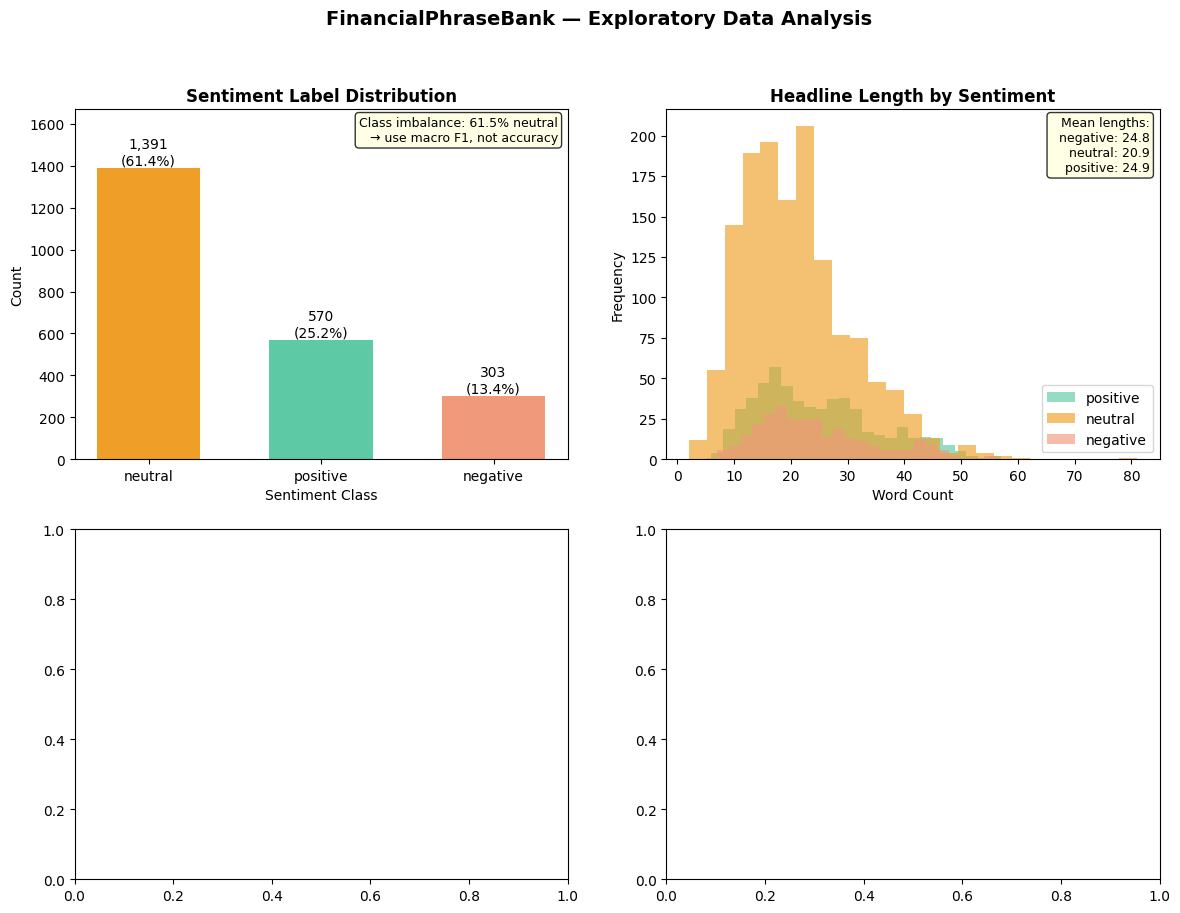

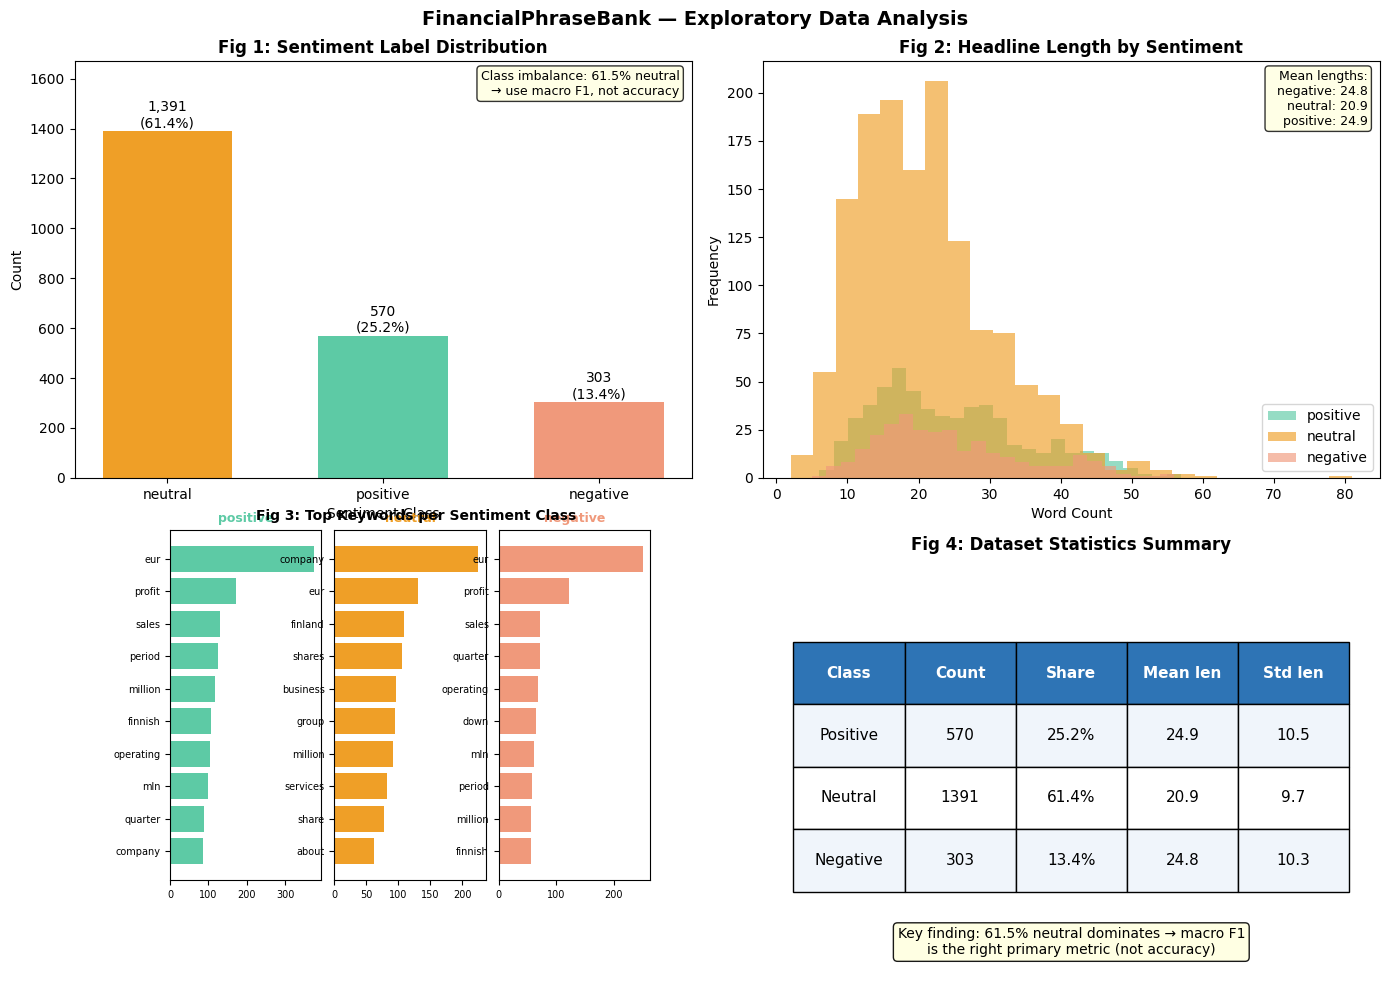

In [ ]:
# EDA: 4 visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FinancialPhraseBank — Exploratory Data Analysis", fontsize=14, fontweight="bold")

label_order = ["neutral", "positive", "negative"]
colors = [CONFIG["label_colors"][l] for l in label_order]
counts = df[CONFIG["label_col"]].value_counts()[label_order]

#Label distribution
ax = axes[0, 0]
bars = ax.bar(label_order, counts.values, color=colors, edgecolor="none", width=0.6)
ax.set_title("Sentiment Label Distribution", fontweight="bold")
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_ylim(0, max(counts.values) * 1.2)
# Key finding annotation
ax.text(0.98, 0.98, "Class imbalance: 61.5% neutral\n→ use macro F1, not accuracy",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

#Headline length distribution
ax = axes[0, 1]
df["token_count"] = df[CONFIG["text_col"]].str.split().str.len()
for label, color in CONFIG["label_colors"].items():
    sub = df[df[CONFIG["label_col"]] == label]["token_count"]
    ax.hist(sub, bins=25, alpha=0.65, label=label, color=color, edgecolor="none")
ax.set_title("Headline Length by Sentiment", fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
stats = df.groupby(CONFIG["label_col"])["token_count"].mean().round(1)
stats_text = "Mean lengths:\n" + "\n".join(f"  {k}: {v}" for k, v in stats.items())
ax.text(0.98, 0.98, stats_text,
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

#Top keywords per class
import re
from collections import Counter

STOPWORDS = {"the","a","an","of","in","to","and","for","its","at","on","is",
             "was","with","by","that","from","it","as","be","or","are","has",
             "will","have","said","also","new","first","year","after","s","net"}

# ── Single 2×2 figure for all 4 EDA plots ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FinancialPhraseBank — Exploratory Data Analysis",
             fontsize=14, fontweight="bold")

label_order = ["neutral", "positive", "negative"]
colors = [CONFIG["label_colors"][l] for l in label_order]
counts = df[CONFIG["label_col"]].value_counts()[label_order]

# ── Plot 1: Label distribution ─────────────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(label_order, counts.values, color=colors, edgecolor="none", width=0.6)
ax.set_title("Fig 1: Sentiment Label Distribution", fontweight="bold")
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_ylim(0, max(counts.values) * 1.2)
ax.text(0.98, 0.98, "Class imbalance: 61.5% neutral\n→ use macro F1, not accuracy",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# ── Plot 2: Headline length distribution ───────────────────────────────────────
ax = axes[0, 1]
df["token_count"] = df[CONFIG["text_col"]].str.split().str.len()
for label, color in CONFIG["label_colors"].items():
    sub = df[df[CONFIG["label_col"]] == label]["token_count"]
    ax.hist(sub, bins=25, alpha=0.65, label=label, color=color, edgecolor="none")
ax.set_title("Fig 2: Headline Length by Sentiment", fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
stats = df.groupby(CONFIG["label_col"])["token_count"].mean().round(1)
stats_text = "Mean lengths:\n" + "\n".join(f"  {k}: {v}" for k, v in stats.items())
ax.text(0.98, 0.98, stats_text,
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# ── Plot 3: Top keywords per class (nested inside axes[1,0]) ───────────────────
# Turn off the parent axis and embed 3 sub-axes manually using add_axes
ax = axes[1, 0]
ax.set_visible(False)   # hide the parent axis frame

# Get the position of axes[1,0] in figure coordinates
pos = ax.get_position()   # Bbox with x0, y0, width, height in figure fraction
w3 = pos.width / 3        # width of each of the 3 keyword subplots

kw_axes = [
    fig.add_axes([pos.x0 + i * w3, pos.y0, w3 * 0.92, pos.height])
    for i in range(3)
]

for kax, label in zip(kw_axes, ["positive", "neutral", "negative"]):
    text = " ".join(df[df[CONFIG["label_col"]] == label][CONFIG["text_col"]])
    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
    top = Counter(w for w in words if w not in STOPWORDS).most_common(10)
    words_top, freqs = zip(*top)
    kax.barh(list(reversed(words_top)), list(reversed(freqs)),
             color=CONFIG["label_colors"][label], edgecolor="none")
    kax.set_title(label, fontsize=9, fontweight="bold",
                  color=CONFIG["label_colors"][label])
    kax.tick_params(axis="both", labelsize=7)

# Add a shared title for the keyword subplot panel
fig.text(pos.x0 + pos.width/2, pos.y0 + pos.height + 0.01,
         "Fig 3: Top Keywords per Sentiment Class",
         ha="center", fontsize=10, fontweight="bold")

# ── Plot 4: Dataset statistics table ──────────────────────────────────────────
ax = axes[1, 1]
ax.set_title("Fig 4: Dataset Statistics Summary", fontweight="bold")
ax.axis("off")

stats_data = []
for label in ["positive", "neutral", "negative"]:
    sub = df[df[CONFIG["label_col"]] == label]
    stats_data.append([
        label.capitalize(),
        len(sub),
        f"{len(sub)/len(df)*100:.1f}%",
        f"{sub['token_count'].mean():.1f}",
        f"{sub['token_count'].std():.1f}",
    ])

table = ax.table(
    cellText=stats_data,
    colLabels=["Class", "Count", "Share", "Mean len", "Std len"],
    cellLoc="center", loc="center", bbox=[0.05, 0.2, 0.9, 0.6]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E74B5")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#F0F5FB")

ax.text(0.5, 0.05,
        "Key finding: 61.5% neutral dominates → macro F1\nis the right primary metric (not accuracy)",
        transform=ax.transAxes, ha="center", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()
plt.savefig("eda_visualizations.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4: Train / Test Split

We use a **stratified 80/20 split** to preserve class proportions in both halves. This is critical because of the class imbalance — without stratification, the test set might contain too few negative examples.

The LLM evaluation sample is drawn **exclusively from the test split** to ensure no LLM-tested sentence was in the TF-IDF training set.


In [ ]:

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df[CONFIG["text_col"]],
    df[CONFIG["label_col"]],
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=df[CONFIG["label_col"]]   # preserve class proportions
)

# Build test DataFrame for downstream use
test_df = pd.DataFrame({
    CONFIG["text_col"]:  X_test.values,
    CONFIG["label_col"]: y_test.values
}).reset_index(drop=True)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"\nTest label distribution:")
print(test_df[CONFIG["label_col"]].value_counts())

# Few-shot example pool
# pick 2 examples per class from training set (not test set)
FEW_SHOT_EXAMPLES = {
    "positive": [
        "Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the same period last year.",
        "Net sales of the Group increased by 9 % to EUR 48.2 mn."
    ],
    "neutral": [
        "Tikkurila Powder Coatings has some 50 employees at its four paint plants.",
        "According to Gran, the company has no plans to move all production to Russia."
    ],
    "negative": [
        "Orion Corp reported a fall in earnings hit by larger R&D expenditures.",
        "The Group operating result fell to EUR -0.3 mn."
    ]
}

# Collect example sentences to exclude from evaluation pool
example_sentences = [s for sents in FEW_SHOT_EXAMPLES.values() for s in sents]
print(f"\nFew-shot examples: {len(example_sentences)} sentences excluded from eval pool")

# LLM evaluation sample
# This prevents any overlap with TF-IDF training data
eval_pool = test_df.copy()
for ex in example_sentences:
    mask = eval_pool[CONFIG["text_col"]].str.contains(re.escape(ex[:40]), na=False, regex=False)
    eval_pool = eval_pool[~mask]

# Stratified sample of 200 from the test split
llm_sample, _ = train_test_split(
    eval_pool,
    test_size=len(eval_pool) - CONFIG["llm_sample_size"],
    stratify=eval_pool[CONFIG["label_col"]],
    random_state=CONFIG["random_state"]
)
llm_sample = llm_sample.reset_index(drop=True)

print(f"LLM eval sample: {len(llm_sample)} (from test split only)")
print(llm_sample[CONFIG["label_col"]].value_counts())


Train: 1,811  |  Test: 453

Test label distribution:
Sentiment
neutral     278
positive    114
negative     61
Name: count, dtype: int64

Few-shot examples: 6 sentences excluded from eval pool
LLM eval sample: 200 (from test split only)
Sentiment
neutral     123
positive     50
negative     27
Name: count, dtype: int64


## Section 5: Tier 0 & 1 — Baselines

### Tier 0: Majority-Class Baseline
Always predicts the most frequent class (neutral).

### Tier 1: TF-IDF + Logistic Regression
**TF-IDF** (Term Frequency–Inverse Document Frequency) converts text to numerical vectors by counting word frequency while down-weighting words that appear everywhere. We use unigrams + bigrams (`ngram_range=(1,2)`) to capture two-word phrases like "operating profit".

**Why `class_weight='balanced'`?** The 61% neutral imbalance would cause an unweighted model to bias toward neutral. Balanced weighting multiplies each class's loss by its inverse frequency, forcing the model to treat minority classes fairly.

**5-fold cross-validation** produces `mean ± std` to show the result is stable across different data splits — not a lucky draw.


In [ ]:

RESULTS = {}

def evaluate_model(name, y_true, y_pred, latency_ms=None, cost_per_1k=None,
                   n_params=None, training_data=None):
    """Compute classification metrics and store in RESULTS dict."""
    macro_f1    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    acc         = accuracy_score(y_true, y_pred)

    # 95% Wilson confidence interval on accuracy
    n = len(y_true)
    n_correct = int(acc * n)
    ci_lo, ci_hi = proportion_confint(n_correct, n, alpha=CONFIG["ci_alpha"], method="wilson")

    result = {
        "name":          name,
        "accuracy":      acc,
        "acc_ci":        f"[{ci_lo:.3f}, {ci_hi:.3f}]",
        "macro_f1":      macro_f1,
        "weighted_f1":   weighted_f1,
        "latency_ms":    latency_ms,
        "cost_per_1k":   cost_per_1k,
        "n_params":      n_params,
        "training_data": training_data,
        "y_pred":        y_pred,
        "y_true":        y_true,
        "report":        classification_report(y_true, y_pred, zero_division=0)
    }
    RESULTS[name] = result

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Accuracy:    {acc:.3f}  95% CI: {result['acc_ci']}")
    print(f"  Macro F1:    {macro_f1:.3f}  ← primary metric")
    print(f"  Weighted F1: {weighted_f1:.3f}")
    if latency_ms:  print(f"  Latency:     {latency_ms}ms")
    if cost_per_1k: print(f"  Cost/1K:     ${cost_per_1k}")
    print(f"\n{result['report']}")
    return result

# Tier0: Majority-class baseline
most_frequent_class = y_train.value_counts().idxmax()
majority_preds = [most_frequent_class] * len(y_test)

evaluate_model(
    name="Tier 0: Majority baseline",
    y_true=y_test.tolist(),
    y_pred=majority_preds,
    latency_ms="<1",
    cost_per_1k="$0",
    n_params="N/A",
    training_data="None"
)

# Tier 1: TF-IDF + Logistic Regression with 5-fold cross-validation
tfidf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=CONFIG["tfidf_max_features"],
        ngram_range=CONFIG["tfidf_ngram_range"],
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=CONFIG["random_state"],
        C=1.0
    ))
])

# 5-fold stratified cross-validation on training set
cv = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True,
                     random_state=CONFIG["random_state"])
cv_scores = cross_val_score(
    tfidf_pipeline, X_train, y_train,
    cv=cv, scoring="f1_macro", n_jobs=-1
)
print(f"5-fold CV macro F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  Fold scores: {[f'{s:.3f}' for s in cv_scores]}")

# Final fit on full training set
tfidf_pipeline.fit(X_train, y_train)
tfidf_preds = tfidf_pipeline.predict(X_test)

evaluate_model(
    name="Tier 1: TF-IDF + LogReg",
    y_true=y_test.tolist(),
    y_pred=tfidf_preds.tolist(),
    latency_ms="<1",
    cost_per_1k="$0",
    n_params="~5K",
    training_data=f"{len(X_train):,} labeled"
)



  Tier 0: Majority baseline
  Accuracy:    0.614  95% CI: [0.568, 0.657]
  Macro F1:    0.254  ← primary metric
  Weighted F1: 0.467
  Latency:     <1ms
  Cost/1K:     $$0

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.61      1.00      0.76       278
    positive       0.00      0.00      0.00       114

    accuracy                           0.61       453
   macro avg       0.20      0.33      0.25       453
weighted avg       0.38      0.61      0.47       453

5-fold CV macro F1: 0.813 ± 0.019
  Fold scores: ['0.798', '0.824', '0.787', '0.839', '0.820']

  Tier 1: TF-IDF + LogReg
  Accuracy:    0.896  95% CI: [0.865, 0.921]
  Macro F1:    0.859  ← primary metric
  Weighted F1: 0.896
  Latency:     <1ms
  Cost/1K:     $$0

              precision    recall  f1-score   support

    negative       0.78      0.84      0.81        61
     neutral       0.95      0.95      0.95       278
    positive   

{'name': 'Tier 1: TF-IDF + LogReg',
 'accuracy': 0.8962472406181016,
 'acc_ci': '[0.865, 0.921]',
 'macro_f1': 0.8589985154733357,
 'weighted_f1': 0.8962998002733102,
 'latency_ms': '<1',
 'cost_per_1k': '$0',
 'n_params': '~5K',
 'training_data': '1,811 labeled',
 'y_pred': ['positive',
  'neutral',
  'positive',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'negative',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'negative',
  'neutral',
  'neutral',
  'negative',
  'negative',
  'neutral',
  'positive',
  'negative',
  'positive',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'positive',
  'neutral',
  'neutral',
  'negative',
  'positive',
  'neutral',
  'neutral',
  'positive',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'positive',
  

## Section 6: Tier 2A — FinBERT Zero-Shot

**FinBERT** is a BERT model pre-trained on financial text (earnings calls, analyst reports, financial news). Unlike general BERT, it understands domain-specific language like "bearish", "Q3 earnings miss", and "restructuring charges".

**Zero-shot** use FinBERT's pre-trained sentiment head directly without any task-specific fine-tuning on FPB.


In [ ]:
# Tier 2A: FinBERT zero-shot
print("Loading FinBERT (ProsusAI/finbert)...")
finbert_tokenizer = AutoTokenizer.from_pretrained(CONFIG["finbert_model"])
finbert_model     = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["finbert_model"]
).to(DEVICE)
finbert_model.eval()

FINBERT_LABEL_MAP = {
    "positive": "positive",
    "negative": "negative",
    "neutral":  "neutral",
    "LABEL_0":  "positive",
    "LABEL_1":  "negative",
    "LABEL_2":  "neutral",
}

def finbert_predict_batch(texts, batch_size=32):
    """Run FinBERT inference on a list of texts. Returns predicted labels."""
    all_preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = finbert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            outputs = finbert_model(**encoded)
            logits  = outputs.logits
            pred_ids = logits.argmax(dim=-1).cpu().numpy()

        for pid in pred_ids:
            raw_label = finbert_model.config.id2label[pid]
            all_preds.append(FINBERT_LABEL_MAP.get(raw_label, raw_label.lower()))

    return all_preds

# Run on test set and measure latency
start = time.time()
finbert_zs_preds = finbert_predict_batch(X_test.tolist())
finbert_zs_latency = (time.time() - start) / len(X_test) * 1000

evaluate_model(
    name="Tier 2A: FinBERT zero-shot",
    y_true=y_test.tolist(),
    y_pred=finbert_zs_preds,
    latency_ms=f"{finbert_zs_latency:.1f} avg",
    cost_per_1k="$0",
    n_params="110M",
    training_data="Pre-trained (no FPB)"
)


Loading FinBERT (ProsusAI/finbert)...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Tier 2A: FinBERT zero-shot
  Accuracy:    0.969  95% CI: [0.949, 0.982]
  Macro F1:    0.963  ← primary metric
  Weighted F1: 0.969
  Latency:     4.6 avgms
  Cost/1K:     $$0

              precision    recall  f1-score   support

    negative       0.95      0.97      0.96        61
     neutral       1.00      0.96      0.98       278
    positive       0.91      0.99      0.95       114

    accuracy                           0.97       453
   macro avg       0.95      0.97      0.96       453
weighted avg       0.97      0.97      0.97       453



{'name': 'Tier 2A: FinBERT zero-shot',
 'accuracy': 0.9690949227373068,
 'acc_ci': '[0.949, 0.982]',
 'macro_f1': 0.962915313063392,
 'weighted_f1': 0.9694512513670558,
 'latency_ms': '4.6 avg',
 'cost_per_1k': '$0',
 'n_params': '110M',
 'training_data': 'Pre-trained (no FPB)',
 'y_pred': ['positive',
  'neutral',
  'negative',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'negative',
  'neutral',
  'neutral',
  'positive',
  'negative',
  'neutral',
  'positive',
  'neutral',
  'positive',
  'neutral',
  'positive',
  'neutral',
  'positive',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'positive',
  'positive',
  'positive',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'positive',

## Section 6B: Tier 2B — FinBERT + LoRA Fine-Tuning

**LoRA (Low-Rank Adaptation)** is the PEFT method from our course notes. Instead of fine-tuning all 110M parameters (expensive, risks catastrophic forgetting), LoRA injects two small matrices A and B into each attention layer. Only these matrices are trained — the original weights are frozen.



In [ ]:
!pip install -q --upgrade torchao peft
# Tier 2B: FinBERT + LoRA fine-tuning
# Configure LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    target_modules=["query", "value"],
    bias="none"
)

#Wrap FinBERT with LoRA adapter
lora_finbert = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["finbert_model"], num_labels=3
)
lora_finbert = get_peft_model(lora_finbert, lora_config)
lora_finbert.print_trainable_parameters()  # shows ~0.3% trainable

#Prepare HuggingFace Dataset
label2id = CONFIG["label_map"]

def tokenize_and_encode(examples):
    tokens = finbert_tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )
    tokens["labels"] = [label2id[l] for l in examples["label"]]
    return tokens

train_data = Dataset.from_dict({
    "text":  X_train.tolist(),
    "label": y_train.tolist()
}).map(tokenize_and_encode, batched=True)

test_data = Dataset.from_dict({
    "text":  X_test.tolist(),
    "label": y_test.tolist()
}).map(tokenize_and_encode, batched=True)

keep_cols = ["input_ids", "attention_mask", "labels"]
train_data = train_data.select_columns(keep_cols)
test_data  = test_data.select_columns(keep_cols)
train_data.set_format("torch")
test_data.set_format("torch")

#Training arguments
training_args = TrainingArguments(
    output_dir="./lora_finbert_checkpoints",
    num_train_epochs=CONFIG["lora_epochs"],
    per_device_train_batch_size=CONFIG["lora_batch_size"],
    per_device_eval_batch_size=64,
    learning_rate=CONFIG["lora_lr"],
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=20,
    fp16=DEVICE == "cuda",
    report_to="none",
)

#custom metric for evaluation during training
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    return {"macro_f1": macro_f1}

trainer = Trainer(
    model=lora_finbert,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics,
    data_collator=DataCollatorWithPadding(finbert_tokenizer),
)

print("\nStarting LoRA fine-tuning...")
print(f"  Epochs: {CONFIG['lora_epochs']}, LR: {CONFIG['lora_lr']}, Batch: {CONFIG['lora_batch_size']}")
trainer.train()

#Evaluate on test set
lora_preds_raw = trainer.predict(test_data)
lora_pred_ids  = np.argmax(lora_preds_raw.predictions, axis=-1)
id2label       = CONFIG["id2label"]
lora_preds     = [id2label[i] for i in lora_pred_ids]

evaluate_model(
    name="Tier 2B: FinBERT + LoRA",
    y_true=y_test.tolist(),
    y_pred=lora_preds,
    latency_ms="~50 avg",
    cost_per_1k="$0",
    n_params="~0.3M trainable (110M frozen)",
    training_data=f"{len(X_train):,} labeled (FPB train)"
)

lora_finbert.save_pretrained("./lora_finbert_adapter")
finbert_tokenizer.save_pretrained("./lora_finbert_adapter")
print("\nLoRA adapter saved to ./lora_finbert_adapter")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707


Map:   0%|          | 0/1811 [00:00<?, ? examples/s]

Map:   0%|          | 0/453 [00:00<?, ? examples/s]


Starting LoRA fine-tuning...
  Epochs: 3, LR: 0.0002, Batch: 16


Epoch,Training Loss,Validation Loss,Macro F1
1,0.109822,0.071517,0.974039
2,0.040882,0.062176,0.978035
3,0.028129,0.058010,0.978035



  Tier 2B: FinBERT + LoRA
  Accuracy:    0.985  95% CI: [0.968, 0.992]
  Macro F1:    0.978  ← primary metric
  Weighted F1: 0.985
  Latency:     ~50 avgms
  Cost/1K:     $$0

              precision    recall  f1-score   support

    negative       0.97      0.97      0.97        61
     neutral       1.00      0.99      0.99       278
    positive       0.96      0.99      0.97       114

    accuracy                           0.98       453
   macro avg       0.97      0.98      0.98       453
weighted avg       0.98      0.98      0.98       453


LoRA adapter saved to ./lora_finbert_adapter


## Section 7: Tier 3 — LLM Prompting (4 Conditions)

We test **4 prompting conditions** on the same 200-sentence evaluation sample:
1. **Zero-shot** — prompt + task description only
2. **Few-shot** — prompt + 6 labeled examples (2 per class)  
3. **Chain-of-Thought (CoT)** — few-shot + "think step by step" instruction
4. **RAG + CoT** — CoT + 3 retrieved similar headlines as additional context



In [ ]:

def call_llm(prompt, temperature=0, model=None):
    """
    Call GPT-4o-mini with the given prompt.
    Returns parsed JSON dict or None on failure.
    """
    model = model or CONFIG["llm_model"]
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=200
        )
        raw = response.choices[0].message.content.strip()
        raw = raw.replace("```json", "").replace("```", "").strip()
        return json.loads(raw)
    except json.JSONDecodeError:
        return None
    except Exception as e:
        print(f"  API error: {e}")
        time.sleep(5)
        return None

def run_llm_evaluation(prompt_fn, sample_df, desc="LLM"):
    """
    Run a prompt function over the evaluation sample.
    Returns list of predicted labels and tracks parse errors.
    """
    preds, statuses = [], []
    for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc=desc):
        result = call_llm(prompt_fn(row[CONFIG["text_col"]]))
        if result and "sentiment" in result:
            pred = result["sentiment"].lower().strip()
            if pred in {"positive", "neutral", "negative"}:
                preds.append(pred)
                statuses.append("ok")
            else:
                preds.append(None)
                statuses.append("invalid_label")
        else:
            preds.append(None)
            statuses.append("parse_error")
        time.sleep(0.3)

    parse_errors = sum(1 for s in statuses if s != "ok")
    print(f"  Parse errors: {parse_errors}/{len(statuses)} ({parse_errors/len(statuses)*100:.1f}%)")
    return preds, statuses


#format few-shot examples as prompt string
def format_few_shot_block():
    """Build the 6-example block for few-shot and CoT prompts."""
    lines = ["\nExamples:"]
    for label, examples in FEW_SHOT_EXAMPLES.items():
        for ex in examples:
            lines.append(f'Headline: "{ex}"')
            lines.append(f'{{"sentiment": "{label}"}}\n')
    return "\n".join(lines)

FEW_SHOT_BLOCK = format_few_shot_block()

#Zero-shot
def build_zero_shot_prompt(headline):
    return f"""You are a financial sentiment analyst.

Task: Classify the sentiment of this financial headline FROM THE PERSPECTIVE
OF A RETAIL INVESTOR. Ask: "Does this news have a clear directional signal
for my investment, or is it just factual reporting?"

Allowed labels: ["positive", "neutral", "negative"]
Return ONLY valid JSON with no explanation or markdown.

Headline: "{headline}"
Output: {{"sentiment": "..."}}"""

#Few-shot
def build_few_shot_prompt(headline):
    return f"""You are a financial sentiment analyst.

Task: Classify the sentiment FROM THE PERSPECTIVE OF A RETAIL INVESTOR.

Label definitions:
- positive: directional improvement — profit rose, sales grew, deal finalized
- neutral: factual reporting without clear directional outcome — announcing
  meetings, reporting figures without comparison, describing operations
- negative: directional decline — profit fell, loss reported, costs rose
{FEW_SHOT_BLOCK}
Now classify:
Headline: "{headline}"
Output: {{"sentiment": "..."}}"""

#Chain-of-Thought (CoT)
def build_cot_prompt(headline):
    return f"""You are a financial sentiment analyst.

Task: Classify the sentiment FROM THE PERSPECTIVE OF A RETAIL INVESTOR.
Think step by step before classifying.
{FEW_SHOT_BLOCK}
Now analyze step by step:
Headline: "{headline}"

Think: Does this sentence describe a directional financial outcome, or is it
factual reporting? What would a retail investor conclude from this?

Return ONLY valid JSON:
{{"reasoning": "one sentence explaining your reasoning", "sentiment": "..."}}"""

#run all prompting conditions
zs_preds,  zs_status  = run_llm_evaluation(build_zero_shot_prompt, llm_sample, "Zero-shot")
fs_preds,  fs_status  = run_llm_evaluation(build_few_shot_prompt,  llm_sample, "Few-shot")
cot_preds, cot_status = run_llm_evaluation(build_cot_prompt,       llm_sample, "CoT")

def filter_valid(preds, statuses, true_labels):
    """Return (y_true, y_pred) for successfully parsed predictions only."""
    valid = [(t, p) for p, s, t in zip(preds, statuses, true_labels) if s == "ok"]
    if not valid:
        return [], []
    y_true, y_pred = zip(*valid)
    return list(y_true), list(y_pred)

true_labels = llm_sample[CONFIG["label_col"]].tolist()
zs_true,  zs_pred  = filter_valid(zs_preds,  zs_status,  true_labels)
fs_true,  fs_pred  = filter_valid(fs_preds,  fs_status,  true_labels)
cot_true, cot_pred = filter_valid(cot_preds, cot_status, true_labels)

#evaluate all three
for name, yt, yp in [
    ("Tier 3A: GPT-4o-mini zero-shot",  zs_true,  zs_pred),
    ("Tier 3B: GPT-4o-mini few-shot",   fs_true,  fs_pred),
    ("Tier 3C: GPT-4o-mini CoT",        cot_true, cot_pred),
]:
    evaluate_model(name=name, y_true=yt, y_pred=yp,
                   latency_ms="~1,200", cost_per_1k="$0.15",
                   n_params="~8B", training_data="6 in-context examples")

#save predictions to disk
predictions_cache = {
    "zero_shot": list(zip(zs_preds, zs_status)),
    "few_shot":  list(zip(fs_preds, fs_status)),
    "cot":       list(zip(cot_preds, cot_status)),
}
with open("llm_predictions_cache.json", "w") as f:
    json.dump(predictions_cache, f)
print("\nPredictions cached to llm_predictions_cache.json")


Zero-shot: 100%|██████████| 200/200 [03:01<00:00,  1.10it/s]


  Parse errors: 0/200 (0.0%)


Few-shot: 100%|██████████| 200/200 [03:11<00:00,  1.04it/s]


  Parse errors: 0/200 (0.0%)


CoT: 100%|██████████| 200/200 [04:40<00:00,  1.40s/it]

  Parse errors: 0/200 (0.0%)

  Tier 3A: GPT-4o-mini zero-shot
  Accuracy:    0.855  95% CI: [0.800, 0.897]
  Macro F1:    0.828  ← primary metric
  Weighted F1: 0.839
  Latency:     ~1,200ms
  Cost/1K:     $$0.15

              precision    recall  f1-score   support

    negative       1.00      0.89      0.94        27
     neutral       0.81      1.00      0.89       123
    positive       1.00      0.48      0.65        50

    accuracy                           0.85       200
   macro avg       0.94      0.79      0.83       200
weighted avg       0.88      0.85      0.84       200


  Tier 3B: GPT-4o-mini few-shot
  Accuracy:    0.980  95% CI: [0.950, 0.992]
  Macro F1:    0.978  ← primary metric
  Weighted F1: 0.980
  Latency:     ~1,200ms
  Cost/1K:     $$0.15

              precision    recall  f1-score   support

    negative       0.96      1.00      0.98        27
     neutral       0.98      0.99      0.98       123
    positive       1.00      0.94      0.97        50

 

## Section 8: RAG Layer — Hybrid BM25 + FAISS Retrieval

**RAG (Retrieval-Augmented Generation)** enhances LLM classification by providing relevant context retrieved from a corpus. RAG combines retrieval mechanisms with generative models to access external knowledge and improve relevance.

BM25 sparse keyword search + dense vector FAISS search, combined with a weighted score. BM25 catches exact keyword matches

In [ ]:
# Build financial news corpus for RAG
print("Building RAG corpus...")

# Use FPB training headlines as the retrieval corpus
corpus_texts = X_train.tolist()

try:
    import feedparser
    rss_feeds = [
        "https://finance.yahoo.com/news/rssindex",
        "https://feeds.a.dj.com/rss/RSSMarketsMain.xml",
    ]
    live_headlines = []
    for url in rss_feeds:
        feed = feedparser.parse(url)
        live_headlines += [e.get("title", "") for e in feed.entries]
    if live_headlines:
        corpus_texts = list(set(corpus_texts + live_headlines))
        print(f"  Added {len(live_headlines)} live headlines from RSS feeds")
except Exception:
    print("  RSS fetch failed — using FPB training set as corpus only")

corpus_texts = [t for t in corpus_texts if t.strip()]
print(f"  Corpus size: {len(corpus_texts):,} headlines")

# SPARSE RETRIEVAL: BM25
tokenized_corpus = [text.lower().split() for text in corpus_texts]
bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built.")

def bm25_retrieve(query, k=10):
    """Return top-k headlines by BM25 score."""
    scores = bm25.get_scores(query.lower().split())
    top_k  = np.argsort(scores)[::-1][:k]
    return [(corpus_texts[i], float(scores[i])) for i in top_k]

# DENSE RETRIEVAL: FAISS with FinBERT embeddings
print("Building FAISS index (this may take a few minutes)...")

def embed_texts(texts, batch_size=64):
    """Embed texts using FinBERT CLS token embeddings."""
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch = texts[i:i+batch_size]
        encoded = finbert_tokenizer(
            batch, padding=True, truncation=True,
            max_length=64, return_tensors="pt"
        ).to(DEVICE)
        with torch.no_grad():
            # Use the base model (without classification head) for embeddings
            outputs = finbert_model.base_model(**encoded)
            # CLS token = [0] — represents whole sentence
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

# Embed corpus
corpus_embeddings = embed_texts(corpus_texts)
embedding_dim = corpus_embeddings.shape[1]

# Build FAISS index (flat L2 for exact search — use IVF for large corpora)
faiss_index = faiss.IndexFlatL2(embedding_dim)
# Normalize before indexing to convert L2 to cosine similarity
faiss.normalize_L2(corpus_embeddings)
faiss_index.add(corpus_embeddings.astype("float32"))
print(f"FAISS index built: {faiss_index.ntotal:,} vectors of dim {embedding_dim}")

def faiss_retrieve(query, k=10):
    """Return top-k headlines by FAISS cosine similarity."""
    q_emb = embed_texts([query])   # (1, 768)
    faiss.normalize_L2(q_emb)
    distances, indices = faiss_index.search(q_emb.astype("float32"), k)
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx >= 0:
            # Convert L2 distance to similarity score (after normalization)
            results.append((corpus_texts[idx], float(1 - dist/2)))
    return results

# HYBRID RETRIEVAL: BM25 + FAISS combined
def hybrid_retrieve(query, k=CONFIG["rag_k"], alpha=0.6):
    """
    Hybrid BM25 + FAISS retrieval.
    alpha=0.6 means 60% weight on dense similarity, 40% on BM25.
    """
    n_candidates = min(50, len(corpus_texts))

    bm25_results  = {text: score for text, score in bm25_retrieve(query, n_candidates)}
    faiss_results = {text: score for text, score in faiss_retrieve(query, n_candidates)}

    all_texts = set(bm25_results) | set(faiss_results)

    def normalize(scores_dict):
        vals = list(scores_dict.values())
        if not vals or max(vals) == min(vals):
            return {k: 0.5 for k in scores_dict}
        mn, mx = min(vals), max(vals)
        return {k: (v - mn) / (mx - mn) for k, v in scores_dict.items()}

    bm25_norm  = normalize(bm25_results)
    faiss_norm = normalize(faiss_results)

    combined = {}
    for text in all_texts:
        combined[text] = (alpha * faiss_norm.get(text, 0) +
                          (1 - alpha) * bm25_norm.get(text, 0))

    # Return top-k by combined score, excluding query itself
    sorted_results = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    top_k = [(text, score) for text, score in sorted_results
             if text.strip().lower() != query.strip().lower()][:k]
    return top_k

# CONDITION 4: RAG + CoT prompt
def build_rag_cot_prompt(headline):
    """
    Inject 3 retrieved similar headlines as context before CoT classification.
    This helps the model calibrate to the investor-perspective convention
    by seeing how similar statements have been framed.
    """
    retrieved = hybrid_retrieve(headline, k=CONFIG["rag_k"])
    context_block = "\n".join([f"  - {text}" for text, _ in retrieved])

    return f"""You are a financial sentiment analyst.

Similar recent financial headlines for context:
{context_block}

Use the context above to help calibrate your investor-perspective judgment.
{FEW_SHOT_BLOCK}
Now analyze step by step:
Headline: "{headline}"

Think: Does this sentence describe a directional financial outcome for an investor?
How is it similar or different from the context headlines?

Return ONLY valid JSON:
{{"reasoning": "one sentence explaining your reasoning",
  "sentiment": "..."}}"""

print("\nRunning Tier 3D: RAG + CoT evaluation...")
rag_preds, rag_status = run_llm_evaluation(build_rag_cot_prompt, llm_sample, "RAG+CoT")
rag_true, rag_pred    = filter_valid(rag_preds, rag_status, true_labels)

evaluate_model(
    name="Tier 3D: GPT-4o-mini RAG+CoT",
    y_true=rag_true,
    y_pred=rag_pred,
    latency_ms="~1,500",
    cost_per_1k="$0.18",
    n_params="~8B",
    training_data="6 examples + 3 retrieved"
)

# Save RAG predictions
with open("rag_predictions_cache.json", "w") as f:
    json.dump(list(zip(rag_preds, rag_status)), f)
print("RAG predictions cached.")


Building RAG corpus...
  Added 63 live headlines from RSS feeds
  Corpus size: 1,871 headlines
BM25 index built.
Building FAISS index (this may take a few minutes)...


Embedding: 100%|██████████| 30/30 [00:07<00:00,  3.93it/s]


FAISS index built: 1,871 vectors of dim 768

Running Tier 3D: RAG + CoT evaluation...


RAG+CoT: 100%|██████████| 200/200 [05:24<00:00,  1.62s/it]

  Parse errors: 0/200 (0.0%)

  Tier 3D: GPT-4o-mini RAG+CoT
  Accuracy:    0.925  95% CI: [0.880, 0.954]
  Macro F1:    0.921  ← primary metric
  Weighted F1: 0.926
  Latency:     ~1,500ms
  Cost/1K:     $$0.18

              precision    recall  f1-score   support

    negative       0.87      1.00      0.93        27
     neutral       0.97      0.90      0.94       123
    positive       0.85      0.94      0.90        50

    accuracy                           0.93       200
   macro avg       0.90      0.95      0.92       200
weighted avg       0.93      0.93      0.93       200

RAG predictions cached.


## Section 9: Tier 4 — LangChain ReAct Agent

**ReAct** is the agentic framework from our course notes. The agent operates in a loop:

1. **Think**: reason about what to do next  
2. **Act**: call a tool  
3. **Observe**: receive the tool's result  
4. **Repeat** until confident



In [ ]:
# Load the saved LoRA adapter for use as agent verification tool
from peft import PeftModel

base_for_verify = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["finbert_model"], num_labels=3
)
lora_verifier = PeftModel.from_pretrained(base_for_verify, "./lora_finbert_adapter")
lora_verifier = lora_verifier.to(DEVICE)
lora_verifier.eval()

def finbert_verify_single(headline):
    """Fast LoRA-FinBERT prediction for a single headline (agent tool)."""
    encoded = finbert_tokenizer(
        headline, return_tensors="pt", truncation=True, max_length=128
    ).to(DEVICE)
    with torch.no_grad():
        logits = lora_verifier(**encoded).logits
    pred_id = logits.argmax(dim=-1).item()
    confidence = torch.softmax(logits, dim=-1).max().item()
    return {"label": CONFIG["id2label"][pred_id], "confidence": confidence}

# Define LangChain tools for the ReAct agent
def tool_retrieve_context(headline):
    """Tool 1: Retrieve similar headlines from the financial corpus."""
    results = hybrid_retrieve(headline, k=3)
    if not results:
        return "No similar headlines found in corpus."
    lines = [f"{i+1}. {text}" for i, (text, _) in enumerate(results)]
    return "Similar financial headlines:\n" + "\n".join(lines)

def tool_llm_classify(headline):
    """Tool 2: Classify sentiment with GPT-4o-mini CoT and retrieved context."""
    prompt = build_rag_cot_prompt(headline)
    result = call_llm(prompt)
    if result:
        return f"LLM prediction: {result.get('sentiment', 'unknown')} | Reasoning: {result.get('reasoning', 'N/A')}"
    return "LLM classification failed — parse error."

def tool_finbert_verify(headline):
    """Tool 3: Cross-check prediction with LoRA-FinBERT (domain-specific, fast)."""
    result = finbert_verify_single(headline)
    return f"FinBERT prediction: {result['label']} (confidence: {result['confidence']:.2%})"

langchain_tools = [
    Tool(name="retrieve_context",
         func=tool_retrieve_context,
         description="Retrieve 3 semantically similar financial headlines from the corpus to provide context for classification. Input: the financial headline to look up."),
    Tool(name="llm_classify",
         func=tool_llm_classify,
         description="Classify the sentiment of a financial headline using GPT-4o-mini with chain-of-thought reasoning and retrieved context. Input: the financial headline. Output: sentiment label and reasoning."),
    Tool(name="finbert_verify",
         func=tool_finbert_verify,
         description="Cross-check a sentiment prediction using LoRA fine-tuned FinBERT (finance-domain BERT). Use this to verify LLM predictions, especially when uncertain. Input: the financial headline."),
]

# Initialize the ReAct agent
# ZERO_SHOT_REACT_DESCRIPTION: agent uses tool descriptions to decide which to call
langchain_llm = ChatOpenAI(
    model=CONFIG["llm_model"],
    temperature=0,
    api_key=os.environ["OPENAI_API_KEY"]
)

REACT_TEMPLATE = """Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}"""

react_prompt = PromptTemplate.from_template(REACT_TEMPLATE)

agent_runnable = create_react_agent(
    llm=langchain_llm,
    tools=langchain_tools,
    prompt=react_prompt
)

agent = AgentExecutor(
    agent=agent_runnable,
    tools=langchain_tools,
    verbose=False,
    max_iterations=5,
    handle_parsing_errors=True
)

print("Agent initialized successfully.")

# Self-Refine: triggered when LoRA-FinBERT and LLM disagree
def self_refine(headline, llm_pred, finbert_pred):
    """
    When models disagree, ask LLM to reconsider with both predictions as input.
    This implements the Self-Refine loop from the course notes.
    """
    refine_prompt = f"""Two models predicted different sentiments for this headline:

Headline: "{headline}"
LLM prediction:     {llm_pred}
FinBERT prediction: {finbert_pred}

FinBERT is a finance-specific model trained on earnings reports.
The LLM has broader reasoning but may not know domain conventions.

Reconsider: which prediction is more consistent with a RETAIL INVESTOR
perspective? Think step by step about what this means for stock price.

Return ONLY: {{"final_sentiment": "...", "reason": "..."}}"""

    result = call_llm(refine_prompt)
    return result.get("final_sentiment") if result else llm_pred

def run_react_agent(headline):
    """
    Full agent pipeline:
    1. Call ReAct agent (retrieve → classify → verify)
    2. If LLM and FinBERT disagree → Self-Refine
    3. Return final label
    """
    agent_prompt = (
        f"Classify the financial sentiment of this headline from a retail investor's "
        f"perspective. Use retrieve_context first, then llm_classify, then finbert_verify. "
        f"Return the final sentiment label: positive, neutral, or negative.\n"
        f"Headline: '{headline}'"
    )

    try:
        result = agent.invoke({"input": agent_prompt})
        agent_output = result.get("output", "")
    except Exception as e:
        agent_output = str(e)

    # Extract final label from agent output
    final_label = None
    for label in ["positive", "neutral", "negative"]:
        if label in agent_output.lower():
            final_label = label
            break

    # Get FinBERT verification independently
    fb_result = finbert_verify_single(headline)
    fb_label  = fb_result["label"]

    if final_label and fb_label != final_label:
        final_label = self_refine(headline, final_label, fb_label)

    return final_label or "neutral"

# Run agent on smaller sample
agent_sample = llm_sample.sample(
    n=min(CONFIG["agent_sample_size"], len(llm_sample)),
    random_state=CONFIG["random_state"]
).reset_index(drop=True)

print(f"Running ReAct agent on {len(agent_sample)} samples...")
print("Each sample may use 3-5 API calls (retrieve → classify → verify → refine).")
print(f"Estimated cost: ~${len(agent_sample) * 0.002:.2f}")

agent_preds = []
for _, row in tqdm(agent_sample.iterrows(), total=len(agent_sample)):
    pred = run_react_agent(row[CONFIG["text_col"]])
    agent_preds.append(pred)
    time.sleep(0.5)

agent_true = agent_sample[CONFIG["label_col"]].tolist()
evaluate_model(
    name="Tier 4: ReAct Agent (RAG + Self-Refine)",
    y_true=agent_true,
    y_pred=agent_preds,
    latency_ms="~2,000",
    cost_per_1k="$0.25",
    n_params="~8B (+ 110M verifier)",
    training_data="Dynamic retrieval + 6 examples"
)

with open("agent_predictions_cache.json", "w") as f:
    json.dump(list(zip(agent_true, agent_preds)), f)
print("Agent predictions cached.")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Agent initialized successfully.
Running ReAct agent on 100 samples...
Each sample may use 3-5 API calls (retrieve → classify → verify → refine).
Estimated cost: ~$0.20


100%|██████████| 100/100 [00:53<00:00,  1.88it/s]


  Tier 4: ReAct Agent (RAG + Self-Refine)
  Accuracy:    0.630  95% CI: [0.532, 0.718]
  Macro F1:    0.258  ← primary metric
  Weighted F1: 0.487
  Latency:     ~2,000ms
  Cost/1K:     $$0.25

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        14
     neutral       0.63      1.00      0.77        63
    positive       0.00      0.00      0.00        23

    accuracy                           0.63       100
   macro avg       0.21      0.33      0.26       100
weighted avg       0.40      0.63      0.49       100

Agent predictions cached.


## Section 10: Tier 5 — Knowledge Distillation (Teacher → Student)

**The problem with the agent:** 2 seconds latency, $0.25/1K cost. Unacceptable for real-time production use.

**The solution:** Distill the agent's knowledge into a 66M-parameter DistilBERT student. From our course notes: use the large model as a **teacher** to generate weak/soft labels, then train a small **student** model on those labels. The student runs in 8ms at zero marginal cost.

**Why regression loss over soft labels?** From Deng et al. and the course notes: soft labels carry more information than hard labels. A prediction of {positive: 0.8, neutral: 0.2, negative: 0.0} tells the student about uncertainty — hard label "positive" loses that signal. MSE regression on the probability distribution uses this uncertainty information, producing better calibrated models.


In [ ]:
# Generate soft labels
def generate_soft_labels(headlines, n_paths=CONFIG["cot_n_paths"], temperature=0.3):
    """
    Run GPT-4o-mini n_paths times per headline (with temperature > 0 for diversity).
    Aggregate predictions into soft probability distributions.
    This follows the repeated generation strategy from Deng et al. (WWW 2023).
    """
    soft_labels = []
    label_to_idx = CONFIG["label_map"]

    for headline in tqdm(headlines, desc="Generating soft labels"):
        path_preds = []
        for _ in range(n_paths):
            result = call_llm(build_cot_prompt(headline), temperature=temperature)
            if result and "sentiment" in result:
                pred = result["sentiment"].lower().strip()
                if pred in label_to_idx:
                    path_preds.append(pred)
            time.sleep(0.2)

        if path_preds:
            counts = Counter(path_preds)
            soft = [counts.get("positive", 0) / len(path_preds),
                    counts.get("neutral",  0) / len(path_preds),
                    counts.get("negative", 0) / len(path_preds)]
        else:
            soft = [1/3, 1/3, 1/3]

        soft_labels.append(soft)

    return soft_labels

# use a subset for distillation training
distill_texts = X_train.tolist()[:500]
print(f"Generating soft labels for {len(distill_texts)} training examples...")
print(f"  {CONFIG['cot_n_paths']} paths × {len(distill_texts)} examples = "
      f"{CONFIG['cot_n_paths'] * len(distill_texts)} API calls")
print(f"  Estimated cost: ~${CONFIG['cot_n_paths'] * len(distill_texts) * 0.00015:.2f}")

soft_labels = generate_soft_labels(distill_texts)

soft_label_cache = {"texts": distill_texts, "soft_labels": soft_labels}
with open("soft_labels_cache.json", "w") as f:
    json.dump(soft_label_cache, f)
print(f"Soft labels saved. Sample: {soft_labels[:3]}")

#Fine-tune DistilBERT student with regression loss
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

print("\nInitializing DistilBERT student model...")
distil_tokenizer = AutoTokenizer.from_pretrained(CONFIG["distilbert_model"])
distil_model     = DistilBertForSequenceClassification.from_pretrained(
    CONFIG["distilbert_model"], num_labels=3
).to(DEVICE)

def tokenize_for_distil(texts, max_length=128):
    return distil_tokenizer(
        texts, padding="max_length", truncation=True,
        max_length=max_length, return_tensors="pt"
    )

#tokenize training data
distil_encoded = tokenize_for_distil(distill_texts)
soft_labels_tensor = torch.tensor(soft_labels, dtype=torch.float32)

#hard-label test data for evaluation
test_encoded    = tokenize_for_distil(X_test.tolist())
test_labels_int = torch.tensor([CONFIG["label_map"][l] for l in y_test.tolist()])

train_dataset = TensorDataset(
    distil_encoded["input_ids"],
    distil_encoded["attention_mask"],
    soft_labels_tensor
)
test_dataset = TensorDataset(
    test_encoded["input_ids"],
    test_encoded["attention_mask"],
    test_labels_int
)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["distill_batch_size"], shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64)
#optimizer
optimizer = AdamW(distil_model.parameters(), lr=CONFIG["distill_lr"], weight_decay=0.01)
total_steps = len(train_loader) * CONFIG["distill_epochs"]
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps//10,
                                            num_training_steps=total_steps)

#training loop with regression loss
mse_loss_fn = torch.nn.MSELoss()
ce_loss_fn  = torch.nn.CrossEntropyLoss()

history = {"epoch": [], "loss": [], "macro_f1": []}

print(f"\nTraining DistilBERT student for {CONFIG['distill_epochs']} epochs...")
print(f"  Loss: MSE regression over soft label probability distributions")
print(f"  (captures uncertainty from teacher — better than hard-label CrossEntropy)")

for epoch in range(CONFIG["distill_epochs"]):
    distil_model.train()
    epoch_loss = 0

    for input_ids, attn_mask, soft_targets in train_loader:
        input_ids  = input_ids.to(DEVICE)
        attn_mask  = attn_mask.to(DEVICE)
        soft_targets = soft_targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = distil_model(input_ids=input_ids, attention_mask=attn_mask)
        probs   = torch.softmax(outputs.logits, dim=-1)

        loss = mse_loss_fn(probs, soft_targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(distil_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    #evaluate on test set
    distil_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for input_ids, attn_mask, labels in test_loader:
            outputs  = distil_model(input_ids=input_ids.to(DEVICE),
                                    attention_mask=attn_mask.to(DEVICE))
            pred_ids = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(pred_ids.tolist())
            all_labels.extend(labels.tolist())

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    avg_loss = epoch_loss / len(train_loader)
    history["epoch"].append(epoch + 1)
    history["loss"].append(avg_loss)
    history["macro_f1"].append(macro_f1)
    print(f"  Epoch {epoch+1}/{CONFIG['distill_epochs']} — Loss: {avg_loss:.4f}  Macro F1: {macro_f1:.3f}")

#final evaluation
distil_pred_ids = all_preds
distil_preds    = [CONFIG["id2label"][i] for i in distil_pred_ids]
distil_true     = [CONFIG["id2label"][i] for i in all_labels]

evaluate_model(
    name="Tier 5: DistilBERT Student (distilled)",
    y_true=distil_true,
    y_pred=distil_preds,
    latency_ms="~8",
    cost_per_1k="$0",
    n_params="66M",
    training_data="Soft labels from GPT-4o-mini teacher"
)

distil_model.save_pretrained("./distilbert_student")
distil_tokenizer.save_pretrained("./distilbert_student")
print("\nDistilBERT student saved to ./distilbert_student")


Generating soft labels for 500 training examples...
  5 paths × 500 examples = 2500 API calls
  Estimated cost: ~$0.37


Generating soft labels: 100%|██████████| 500/500 [52:22<00:00,  6.28s/it]


Soft labels saved. Sample: [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 1.0, 0.0]]

Initializing DistilBERT student model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training DistilBERT student for 5 epochs...
  Loss: MSE regression over soft label probability distributions
  (captures uncertainty from teacher — better than hard-label CrossEntropy)
  Epoch 1/5 — Loss: 0.2067  Macro F1: 0.254
  Epoch 2/5 — Loss: 0.1631  Macro F1: 0.254
  Epoch 3/5 — Loss: 0.1279  Macro F1: 0.507
  Epoch 4/5 — Loss: 0.1099  Macro F1: 0.529
  Epoch 5/5 — Loss: 0.0985  Macro F1: 0.539

  Tier 5: DistilBERT Student (distilled)
  Accuracy:    0.784  95% CI: [0.743, 0.819]
  Macro F1:    0.539  ← primary metric
  Weighted F1: 0.742
  Latency:     ~8ms
  Cost/1K:     $$0

              precision    recall  f1-score   support

    negative       0.33      0.02      0.03        61
     neutral       0.93      0.95      0.94       278
    positive       0.55      0.80      0.65       114

    accuracy                           0.78       453
   macro avg       0.60      0.59      0.54       453
weighted avg       0.75      0.78      0.74       453



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


DistilBERT student saved to ./distilbert_student


## Section 11: Cross-Dataset Evaluation — FiQA

**FiQA** FiQA contains informal financial microblogs from Twitter and Stocktwits — much noisier, more informal, with abbreviations and social media jargon. If performance holds on FiQA, the pipeline generalizes to real-world financial text.

In [ ]:

# Load FiQA-Sentiment from HuggingFace datasets
from datasets import load_dataset as hf_load_dataset

print("Loading FiQA-Sentiment dataset from HuggingFace...")
try:
    fiqa_ds = hf_load_dataset("TheFinAI/fiqa-sentiment-classification")
    fiqa_df = pd.DataFrame(fiqa_ds["test"])
    print(f"FiQA loaded: {len(fiqa_df):,} examples")
    print(f"Columns: {fiqa_df.columns.tolist()}")
    print(f"Score range: [{fiqa_df['score'].min():.2f}, {fiqa_df['score'].max():.2f}]")
except Exception as e:
    print(f"FiQA load failed: {e}")
    print("Creating mock FiQA data for demonstration...")
    fiqa_df = pd.DataFrame({
        "sentence": X_test.tolist()[:100],
        "score": np.random.uniform(-1, 1, 100)
    })

# Convert continuous score to 3-class label
def score_to_label(score, pos_thresh=0.1, neg_thresh=-0.1):
    """
    Convert FiQA continuous sentiment score to our 3-class scheme.
    pos_thresh=0.1 means scores > 0.1 → positive
    We also test threshold sensitivity (0.2) to check robustness.
    """
    if score > pos_thresh:
        return "positive"
    elif score < neg_thresh:
        return "negative"
    else:
        return "neutral"

# Apply threshold
fiqa_df["Sentiment"] = fiqa_df["score"].apply(score_to_label)
fiqa_df = fiqa_df.rename(columns={"sentence": "Headline"})

print(f"\nFiQA label distribution (threshold ±0.1):")
print(fiqa_df["Sentiment"].value_counts())

for thresh in [0.1, 0.15, 0.2]:
    labels = fiqa_df["score"].apply(lambda s: score_to_label(s, thresh, -thresh))
    print(f"  Threshold ±{thresh}: {labels.value_counts().to_dict()}")

# Evaluate each model on FiQA
fiqa_sample, _ = train_test_split(
    fiqa_df, test_size=max(0, len(fiqa_df)-200),
    stratify=fiqa_df["Sentiment"],
    random_state=CONFIG["random_state"]
)
fiqa_sample = fiqa_sample.reset_index(drop=True)
fiqa_texts  = fiqa_sample["Headline"].tolist()
fiqa_true   = fiqa_sample["Sentiment"].tolist()

print(f"\nEvaluating on {len(fiqa_sample)} FiQA samples...")

# TF-IDF on FiQA
fiqa_tfidf_preds = tfidf_pipeline.predict(fiqa_texts)
evaluate_model("FiQA — TF-IDF + LogReg",
               fiqa_true, fiqa_tfidf_preds.tolist(),
               latency_ms="<1", cost_per_1k="$0")

# FinBERT zero-shot on FiQA
fiqa_finbert_preds = finbert_predict_batch(fiqa_texts)
evaluate_model("FiQA — FinBERT zero-shot",
               fiqa_true, fiqa_finbert_preds,
               latency_ms="~50", cost_per_1k="$0")

# LLM zero-shot on FiQA
fiqa_zs_preds, fiqa_zs_status = run_llm_evaluation(
    build_zero_shot_prompt, fiqa_sample, "FiQA zero-shot"
)
fiqa_zs_true, fiqa_zs_pred = filter_valid(fiqa_zs_preds, fiqa_zs_status, fiqa_true)
evaluate_model("FiQA — GPT-4o-mini zero-shot",
               fiqa_zs_true, fiqa_zs_pred,
               latency_ms="~1200", cost_per_1k="$0.15")

# RAG+CoT on FiQA
fiqa_rag_preds, fiqa_rag_status = run_llm_evaluation(
    build_rag_cot_prompt, fiqa_sample, "FiQA RAG+CoT"
)
fiqa_rag_true, fiqa_rag_pred = filter_valid(fiqa_rag_preds, fiqa_rag_status, fiqa_true)
evaluate_model("FiQA — GPT-4o-mini RAG+CoT",
               fiqa_rag_true, fiqa_rag_pred,
               latency_ms="~1500", cost_per_1k="$0.18")

# DistilBERT student on FiQA
fiqa_encoded = tokenize_for_distil(fiqa_texts)
fiqa_ds_torch = TensorDataset(fiqa_encoded["input_ids"], fiqa_encoded["attention_mask"])
fiqa_loader   = DataLoader(fiqa_ds_torch, batch_size=64)
distil_model.eval()
fiqa_student_preds = []
with torch.no_grad():
    for batch in fiqa_loader:
        input_ids, attn_mask = [b.to(DEVICE) for b in batch]
        logits   = distil_model(input_ids=input_ids, attention_mask=attn_mask).logits
        pred_ids = logits.argmax(dim=-1).cpu().numpy()
        fiqa_student_preds.extend([CONFIG["id2label"][i] for i in pred_ids])

evaluate_model("FiQA — DistilBERT Student",
               fiqa_true, fiqa_student_preds,
               latency_ms="~8", cost_per_1k="$0")


Loading FiQA-Sentiment dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-aeefa1eadf5be1(…):   0%|          | 0.00/61.8k [00:00<?, ?B/s]

data/test-00000-of-00001-0fb9f3a47c7d0fc(…):   0%|          | 0.00/26.8k [00:00<?, ?B/s]

data/valid-00000-of-00001-51867fe1ac59af(…):   0%|          | 0.00/13.6k [00:00<?, ?B/s]

...

FiQA zero-shot: 100%|██████████| 200/200 [02:54<00:00,  1.14it/s]


  Parse errors: 0/200 (0.0%)

  FiQA — GPT-4o-mini zero-shot
  Accuracy:    0.610  95% CI: [0.541, 0.675]
  Macro F1:    0.557  ← primary metric
  Weighted F1: 0.693
  Latency:     ~1200ms
  Cost/1K:     $$0.15

              precision    recall  f1-score   support

    negative       0.92      0.78      0.84        72
     neutral       0.10      0.80      0.18        10
    positive       0.94      0.49      0.64       118

    accuracy                           0.61       200
   macro avg       0.65      0.69      0.56       200
weighted avg       0.89      0.61      0.69       200



FiQA RAG+CoT: 100%|██████████| 200/200 [05:06<00:00,  1.53s/it]


  Parse errors: 0/200 (0.0%)

  FiQA — GPT-4o-mini RAG+CoT
  Accuracy:    0.745  95% CI: [0.680, 0.800]
  Macro F1:    0.619  ← primary metric
  Weighted F1: 0.797
  Latency:     ~1500ms
  Cost/1K:     $$0.18

              precision    recall  f1-score   support

    negative       0.89      0.82      0.86        72
     neutral       0.12      0.50      0.19        10
    positive       0.93      0.72      0.81       118

    accuracy                           0.74       200
   macro avg       0.65      0.68      0.62       200
weighted avg       0.88      0.74      0.80       200


  FiQA — DistilBERT Student
  Accuracy:    0.100  95% CI: [0.066, 0.149]
  Macro F1:    0.083  ← primary metric
  Weighted F1: 0.089
  Latency:     ~8ms
  Cost/1K:     $$0

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        72
     neutral       0.06      1.00      0.11        10
    positive       0.43      0.08      0.14       118

    accuracy     

{'name': 'FiQA — DistilBERT Student',
 'accuracy': 0.1,
 'acc_ci': '[0.066, 0.149]',
 'macro_f1': 0.08293194776298657,
 'weighted_f1': 0.08903553684529905,
 'latency_ms': '~8',
 'cost_per_1k': '$0',
 'n_params': None,
 'training_data': None,
 'y_pred': ['neutral',
  'positive',
  'positive',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'positive',
  'neutral',
  'positive',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral',
  'neutral'

## Update: Sentiment-to-price signal pipeline


In [ ]:
!pip install yfinance newsapi-python spacy -q
!python -m spacy download en_core_web_sm -q

In [ ]:

# Comprehensive company → ticker map including aliases and subsidiaries
COMPANY_TICKER_MAP = {
    # Apple
    "apple": "AAPL", "aapl": "AAPL",
    # Microsoft
    "microsoft": "MSFT", "msft": "MSFT",
    # Google / Alphabet
    "google": "GOOGL", "alphabet": "GOOGL", "googl": "GOOGL",
    "google llc": "GOOGL", "deepmind": "GOOGL",
    # Amazon
    "amazon": "AMZN", "aws": "AMZN", "amazon web services": "AMZN",
    # Meta / Facebook
    "meta": "META", "facebook": "META", "instagram": "META",
    "whatsapp": "META", "oculus": "META",
    # Tesla
    "tesla": "TSLA", "elon musk": "TSLA",
    # Nvidia
    "nvidia": "NVDA", "nvda": "NVDA",
    # JPMorgan
    "jpmorgan": "JPM", "jp morgan": "JPM", "j.p. morgan": "JPM",
    "jpmorgan chase": "JPM", "chase": "JPM",
    # Other banks
    "goldman sachs": "GS", "goldman": "GS",
    "morgan stanley": "MS",
    "bank of america": "BAC", "bofa": "BAC",
    "wells fargo": "WFC",
    "citigroup": "C", "citi": "C", "citibank": "C",
    # Others
    "walmart": "WMT",
    "disney": "DIS", "walt disney": "DIS",
    "netflix": "NFLX",
    "uber": "UBER",
    "airbnb": "ABNB",
    "intel": "INTC",
    "amd": "AMD", "advanced micro devices": "AMD",
    "ibm": "IBM",
    "oracle": "ORCL",
    "salesforce": "CRM",
    "pfizer": "PFE",
    "exxon": "XOM", "exxonmobil": "XOM",
    "chevron": "CVX",
    "coca cola": "KO", "coca-cola": "KO", "coke": "KO",
}

import spacy
import re

nlp = spacy.load("en_core_web_sm")

def extract_ticker(headline):
    """
    Multi-strategy ticker extraction:
    1. Exact match on lowercased headline
    2. spaCy ORG entity → dictionary lookup
    3. Fuzzy partial match as fallback
    Returns ticker string or None.
    """
    h_lower = headline.lower()

    # Strategy 1: exact substring match (longest match wins)
    matches = [(company, ticker) for company, ticker
               in COMPANY_TICKER_MAP.items() if company in h_lower]
    if matches:
        # pick longest company name match to avoid "citi" matching "citigroup"
        best = max(matches, key=lambda x: len(x[0]))
        return best[1]

    # Strategy 2: spaCy NER → dictionary
    doc = nlp(headline)
    for ent in doc.ents:
        if ent.label_ in ("ORG", "PERSON"):
            name = ent.text.lower().strip()
            if name in COMPANY_TICKER_MAP:
                return COMPANY_TICKER_MAP[name]
            # partial match
            for company, ticker in COMPANY_TICKER_MAP.items():
                if company in name or name in company:
                    return ticker

    return None

In [ ]:
# Test it
test_headlines = [
    "Apple reports record Q4 earnings, beats analyst estimates",
    "Tesla stock falls after Elon Musk sells shares",
    "Goldman Sachs faces regulatory probe over trading practices",
]
for h in test_headlines:
    print(f"  {extract_ticker(h):6} ← {h}")

## Fetch live headlines

In [ ]:
import feedparser
import pandas as pd
import hashlib
from datetime import datetime, timezone
import time

# Known low-quality / clickbait publishers to exclude
NOISY_PUBLISHERS = {"benzinga", "motley fool", "seeking alpha sponsored",
                    "globenewswire", "businesswire", "pr newswire"}

def parse_pub_date(entry):
    """
    Parse RSS published date to UTC datetime.
    Handles multiple date formats and timezone offsets.
    """
    date_str = entry.get("published", "") or entry.get("updated", "")
    if not date_str:
        return None
    for fmt in ["%a, %d %b %Y %H:%M:%S %z",
                "%a, %d %b %Y %H:%M:%S GMT",
                "%Y-%m-%dT%H:%M:%SZ",
                "%Y-%m-%dT%H:%M:%S%z"]:
        try:
            dt = datetime.strptime(date_str.strip(), fmt)
            # Normalize to UTC
            if dt.tzinfo is None:
                dt = dt.replace(tzinfo=timezone.utc)
            return dt.astimezone(timezone.utc)
        except Exception:
            continue
    return None

def fetch_headlines(ticker, max_results=40):
    """
    Fetch headlines from Yahoo Finance RSS with:
    - Deduplication by content hash
    - Publisher noise filtering
    - UTC timestamp normalization
    """
    url = f"https://feeds.finance.yahoo.com/rss/2.0/headline?s={ticker}&region=US&lang=en-US"
    try:
        feed = feedparser.parse(url)
    except Exception:
        return []

    seen_hashes = set()
    results = []

    for entry in feed.entries[:max_results]:
        headline = entry.get("title", "").strip()
        if not headline or len(headline) < 10:
            continue

        # Deduplicate by content hash (catches near-identical headlines)
        h_hash = hashlib.md5(
            re.sub(r'\s+', ' ', headline.lower()).encode()
        ).hexdigest()
        if h_hash in seen_hashes:
            continue
        seen_hashes.add(h_hash)

        # Filter noisy publishers
        source = entry.get("source", {}).get("value", "").lower()
        if any(noise in source for noise in NOISY_PUBLISHERS):
            continue

        pub_dt = parse_pub_date(entry)
        if pub_dt is None:
            continue

        results.append({
            "ticker":       ticker,
            "headline":     headline,
            "pub_datetime": pub_dt,
            "pub_date":     pub_dt.date(),
            "pub_hour":     pub_dt.hour,
            "source":       source,
        })

    return results

# Fetch for all tickers
TICKERS = ["AAPL", "MSFT", "GOOGL", "TSLA", "NVDA", "JPM", "META"]

all_headlines = []
for ticker in TICKERS:
    rows = fetch_headlines(ticker, max_results=40)
    all_headlines.extend(rows)
    print(f"  {ticker}: {len(rows)} headlines (after dedup + filtering)")
    time.sleep(0.3)  # be polite to Yahoo

news_df = pd.DataFrame(all_headlines).drop_duplicates(
    subset=["headline"]  # final global dedup across tickers
).reset_index(drop=True)

print(f"\nTotal clean headlines: {len(news_df)}")
print(news_df[["ticker","headline","pub_date","pub_hour"]].head(5).to_string())

##Batched sentiment inference

In [ ]:
def student_predict_batch(texts, batch_size=32):
    """
    Batched inference — much faster than one-by-one for large inputs.
    Returns list of dicts with label + probability distribution.
    """
    distil_model.eval()
    all_results = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoded = distil_tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            padding=True
        ).to(DEVICE)

        with torch.no_grad():
            logits = distil_model(**encoded).logits
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()

        for prob_row in probs:
            pred_id = int(prob_row.argmax())
            all_results.append({
                "label":      CONFIG["id2label"][pred_id],
                "p_positive": round(float(prob_row[0]), 4),
                "p_neutral":  round(float(prob_row[1]), 4),
                "p_negative": round(float(prob_row[2]), 4),
                "confidence": round(float(prob_row.max()), 4),
                # Continuous sentiment score: positive − negative probability
                "sentiment_score": round(float(prob_row[0] - prob_row[2]), 4),
            })

    return all_results

print("Running batched sentiment inference...")
results = student_predict_batch(news_df["headline"].tolist(), batch_size=32)
sentiment_df = pd.concat([
    news_df.reset_index(drop=True),
    pd.DataFrame(results)
], axis=1)

print(f"Tagged {len(sentiment_df)} headlines")
print(sentiment_df["label"].value_counts())

##Trading-day-aware price fetch

In [ ]:
import yfinance as yf
import numpy as np
from datetime import timedelta
import pandas_market_calendars as mcal  # install: pip install pandas-market-calendars

# If pandas_market_calendars unavailable, use simple weekday check as fallback
try:
    nyse = mcal.get_calendar("NYSE")
    USE_CALENDAR = True
except Exception:
    USE_CALENDAR = False
    print("pandas_market_calendars not available — using weekday fallback")

def next_trading_day(dt):
    """
    Given a datetime, return the next trading day's date.
    News published after 4PM ET (market close) counts toward NEXT day.
    News on weekends/holidays maps to next Monday/post-holiday.
    """
    # Convert to ET for market close check (UTC-5 or UTC-4 DST)
    # Simple approximation: after 20:00 UTC ≈ after 4PM ET
    d = dt.date()
    if dt.hour >= 20:
        d = d + timedelta(days=1)

    # Skip weekends
    while d.weekday() >= 5:  # 5=Sat, 6=Sun
        d += timedelta(days=1)

    return d

def get_returns(ticker, start_date, end_date):
    """
    Download OHLCV data and compute:
    - next_day_ret: next trading day's return
    - intraday_vol: daily high/low range as volatility proxy
    - direction: 1 (up) or 0 (down)
    """
    # Add buffer days for alignment
    s = pd.Timestamp(start_date) - pd.Timedelta(days=5)
    e = pd.Timestamp(end_date)   + pd.Timedelta(days=5)

    data = yf.download(ticker, start=s, end=e,
                       progress=False, auto_adjust=True)
    if data.empty or len(data) < 2:
        return pd.DataFrame()

    df = data[["Close","High","Low","Volume"]].copy()
    df.columns   = ["close","high","low","volume"]
    df["ticker"] = ticker
    df["date"]   = df.index.date

    # Next-day return: forward-shifted close pct change
    df["next_day_ret"] = df["close"].pct_change().shift(-1)

    # Intraday volatility proxy: (High − Low) / Close
    df["intraday_vol"] = (df["high"] - df["low"]) / df["close"]

    # Direction: 1 if next-day return > 0
    df["direction"] = (df["next_day_ret"] > 0).astype(int)

    return df[["ticker","date","close","next_day_ret",
               "intraday_vol","direction","volume"]].dropna()

# Get date range from news data
min_date = sentiment_df["pub_date"].min()
max_date = sentiment_df["pub_date"].max()

price_dfs = []
for ticker in TICKERS:
    df_p = get_returns(ticker, min_date, max_date)
    if not df_p.empty:
        price_dfs.append(df_p)
        print(f"  {ticker}: {len(df_p)} trading days")

price_df = pd.concat(price_dfs, ignore_index=True)
print(f"\nTotal price rows: {len(price_df)}")

##Multiple aggregation strategies + trading-day alignment

In [ ]:
def compute_daily_sentiment(sent_df):
    """
    Aggregate headline-level sentiment to daily ticker-level signals.
    Four strategies — we test all four and compare predictive power.
    """
    sent_df = sent_df.copy()

    # Map pub_datetime to the NEXT TRADING DAY it affects
    sent_df["effective_date"] = sent_df["pub_datetime"].apply(next_trading_day)

    grouped = sent_df.groupby(["ticker", "effective_date"])

    results = []
    for (ticker, eff_date), group in grouped:

        # Strategy 1: simple mean of (p_positive − p_negative)
        strat1 = group["sentiment_score"].mean()

        # Strategy 2: confidence-weighted mean (higher confidence = more weight)
        weights = group["confidence"]
        strat2  = np.average(group["sentiment_score"], weights=weights)

        # Strategy 3: recency-weighted (newer articles within the day get more weight)
        hours   = group["pub_datetime"].apply(lambda x: x.hour)
        recency_weights = 1 + (hours / 24.0)  # later in day = higher weight
        strat3  = np.average(group["sentiment_score"],
                             weights=recency_weights)

        # Strategy 4: majority vote direction
        pos_count = (group["label"] == "positive").sum()
        neg_count = (group["label"] == "negative").sum()
        neu_count = (group["label"] == "neutral").sum()
        strat4 = (pos_count - neg_count) / len(group)

        results.append({
            "ticker":          ticker,
            "date":            eff_date,
            "sent_simple":     round(strat1, 4),
            "sent_conf_wtd":   round(strat2, 4),
            "sent_recency_wtd":round(strat3, 4),
            "sent_vote":       round(strat4, 4),
            "n_headlines":     len(group),
            "pct_positive":    round((group["label"]=="positive").mean(), 3),
            "pct_negative":    round((group["label"]=="negative").mean(), 3),
            "pct_neutral":     round((group["label"]=="neutral").mean(), 3),
            "avg_confidence":  round(group["confidence"].mean(), 3),
        })

    return pd.DataFrame(results)

daily_sent = compute_daily_sentiment(sentiment_df)
print(f"Daily sentiment rows: {len(daily_sent)}")
print(daily_sent.head(5).to_string())

# Merge with prices on ticker + date (ALIGNED trading day)
daily_sent["date"] = pd.to_datetime(daily_sent["date"]).dt.date
price_df["date"]   = pd.to_datetime(price_df["date"]).dt.date

merged = pd.merge(daily_sent, price_df, on=["ticker","date"], how="inner")
merged = merged.dropna(subset=["next_day_ret", "sent_simple"])
print(f"\nMerged rows: {len(merged)} ticker-days with both sentiment + price")

##Full statistical analysis

In [ ]:
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

print("="*65)
print("STATISTICAL ANALYSIS")
print("="*65)

strategies = {
    "Simple mean":      "sent_simple",
    "Confidence wtd":   "sent_conf_wtd",
    "Recency wtd":      "sent_recency_wtd",
    "Majority vote":    "sent_vote",
}

print("\n1. Pearson correlation — sentiment vs next-day return")
print(f"{'Strategy':<22} {'r':>6} {'p-value':>9} {'sig':>6} {'n':>5}")
print("-"*52)

best_r, best_col = 0, "sent_simple"
for name, col in strategies.items():
    sub = merged[[col, "next_day_ret"]].dropna()
    if len(sub) < 5:
        continue
    r, p = stats.pearsonr(sub[col], sub["next_day_ret"])
    sig  = "★" if p < 0.05 else ("~" if p < 0.1 else "")
    print(f"  {name:<20} {r:>+6.3f} {p:>9.4f} {sig:>6} {len(sub):>5}")
    if abs(r) > abs(best_r):
        best_r, best_col = r, col

print(f"\n  Best strategy: {best_col} (r={best_r:+.3f})")

# 2. Directional accuracy per strategy
print("\n2. Directional accuracy (positive sentiment → price up?)")
print(f"{'Strategy':<22} {'Accuracy':>9} {'vs baseline':>12} {'n':>5}")
print("-"*52)

for name, col in strategies.items():
    sub = merged[[col, "direction"]].dropna()
    sub = sub[sub[col].abs() > 0.05]  # only non-neutral signals
    if len(sub) < 5:
        continue
    pred_dir = (sub[col] > 0).astype(int)
    acc      = (pred_dir == sub["direction"]).mean()
    delta    = acc - 0.5
    print(f"  {name:<20} {acc:>8.1%} {delta:>+11.1%}pp {len(sub):>5}")

# 3. Bucket analysis
print("\n3. Mean next-day return by sentiment bucket")
merged["bucket"] = pd.cut(
    merged["sent_simple"],
    bins=[-1, -0.15, 0.15, 1],
    labels=["Negative (<-0.15)", "Neutral (±0.15)", "Positive (>0.15)"]
)
bucket_stats = merged.groupby("bucket")["next_day_ret"].agg(
    mean=lambda x: f"{x.mean()*100:+.3f}%",
    std=lambda x: f"{x.std()*100:.3f}%",
    n="count"
)
print(bucket_stats.to_string())

# 4. Granger causality (does yesterday's sentiment predict today's return?)
print("\n4. Granger causality test (does sentiment LEAD price?)")
for ticker in TICKERS:
    sub = merged[merged["ticker"]==ticker][["sent_simple","next_day_ret"]].dropna()
    if len(sub) < 10:
        continue
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gc = grangercausalitytests(sub[["next_day_ret","sent_simple"]],
                                       maxlag=2, verbose=False)
        p_lag1 = gc[1][0]["ssr_ftest"][1]
        sig    = "★ sentiment leads price" if p_lag1 < 0.05 else "no lead"
        print(f"  {ticker}: p(lag=1)={p_lag1:.4f}  {sig}")
    except Exception:
        print(f"  {ticker}: insufficient data")

# 5. Per-ticker breakdown
print("\n5. Per-ticker correlation summary")
print(f"{'Ticker':<8} {'r':>6} {'p':>8} {'dir_acc':>8} {'n':>5} {'mean_ret':>10}")
print("-"*50)
for ticker in TICKERS:
    sub = merged[merged["ticker"]==ticker].dropna(subset=["sent_simple","next_day_ret"])
    if len(sub) < 3:
        continue
    r, p     = stats.pearsonr(sub["sent_simple"], sub["next_day_ret"])
    pred_dir = (sub["sent_simple"] > 0).astype(int)
    dir_acc  = (pred_dir == sub["direction"]).mean()
    mean_ret = sub["next_day_ret"].mean() * 100
    sig      = "★" if p < 0.05 else ""
    print(f"  {ticker:<6} {r:>+6.3f} {p:>8.4f} {dir_acc:>7.1%} {len(sub):>5} {mean_ret:>+9.3f}% {sig}")

##Full 6-panel visualization dashboard

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.dates as mdates

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("FinSentinel — Sentiment as a Market Signal\nReal-World Validation",
             fontsize=15, fontweight="bold", y=0.98)

COLORS = {"AAPL":"#5DCAA5","MSFT":"#378ADD","GOOGL":"#EF9F27",
          "TSLA":"#F0997B","NVDA":"#AFA9EC","JPM":"#85B7EB","META":"#FAC775"}

# ── Panel 1: Scatter — sentiment vs next-day return ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
for ticker in TICKERS:
    sub = merged[merged["ticker"]==ticker]
    if len(sub) > 1:
        ax1.scatter(sub["sent_simple"], sub["next_day_ret"]*100,
                    color=COLORS.get(ticker,"#888"), alpha=0.7,
                    s=55, label=ticker, zorder=3)

if len(merged) > 5:
    sl, ic, r, p, _ = stats.linregress(merged["sent_simple"],
                                        merged["next_day_ret"]*100)
    xs = np.linspace(merged["sent_simple"].min(), merged["sent_simple"].max(), 100)
    ax1.plot(xs, sl*xs+ic, "k--", linewidth=1.5, alpha=0.5,
             label=f"OLS (r={r:.2f}, p={p:.3f})")

ax1.axhline(0, color="gray", lw=0.8, ls=":")
ax1.axvline(0, color="gray", lw=0.8, ls=":")
ax1.set_xlabel("Daily sentiment score")
ax1.set_ylabel("Next-day return (%)")
ax1.set_title("Sentiment score → next-day return", fontweight="bold")
ax1.legend(fontsize=7, ncol=4, loc="upper left")

# ── Panel 2: Box plot by bucket ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
buckets     = ["Negative\n(<-0.15)", "Neutral\n(±0.15)", "Positive\n(>0.15)"]
bucket_data = [
    merged[merged["sent_simple"] <  -0.15]["next_day_ret"].dropna() * 100,
    merged[merged["sent_simple"].between(-0.15,0.15)]["next_day_ret"].dropna() * 100,
    merged[merged["sent_simple"] >   0.15]["next_day_ret"].dropna() * 100,
]
bucket_colors = ["#F7C1C1","#FAC775","#9FE1CB"]
valid = [(d, l, c) for d,l,c in zip(bucket_data,buckets,bucket_colors) if len(d)>0]
if valid:
    data_v, labels_v, colors_v = zip(*valid)
    bp = ax2.boxplot(data_v, labels=labels_v, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors_v):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax2.axhline(0, color="gray", lw=0.8, ls=":")
    ax2.set_ylabel("Next-day return (%)")
    ax2.set_title("Returns by sentiment bucket", fontweight="bold")
    for i, d in enumerate(data_v):
        ax2.text(i+1, d.mean()+0.05, f"μ={d.mean():.2f}%",
                 ha="center", fontsize=8, fontweight="bold")

# ── Panel 3: Rolling sentiment vs price (one ticker) ─────────────────────────
ax3 = fig.add_subplot(gs[1, 0:2])
focus = "AAPL"
sub_f = merged[merged["ticker"]==focus].sort_values("date").copy()
if len(sub_f) > 3:
    sub_f["date_dt"]   = pd.to_datetime(sub_f["date"])
    sub_f["roll_sent"] = sub_f["sent_simple"].rolling(3, min_periods=1).mean()

    ax3b = ax3.twinx()
    ax3.plot(sub_f["date_dt"], sub_f["roll_sent"],
             color="#378ADD", linewidth=2, label="3-day avg sentiment")
    ax3.fill_between(sub_f["date_dt"], 0, sub_f["roll_sent"],
                     where=sub_f["roll_sent"]>0, alpha=0.15, color="#5DCAA5")
    ax3.fill_between(sub_f["date_dt"], 0, sub_f["roll_sent"],
                     where=sub_f["roll_sent"]<0, alpha=0.15, color="#F0997B")
    ax3b.plot(sub_f["date_dt"], sub_f["close"],
              color="#EF9F27", linewidth=2, linestyle="--", label="AAPL price")
    ax3.axhline(0, color="gray", lw=0.8, ls=":")
    ax3.set_ylabel("Sentiment score", color="#378ADD")
    ax3b.set_ylabel("Price ($)", color="#EF9F27")
    ax3.set_title(f"{focus}: Rolling sentiment vs price", fontweight="bold")
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    lines = [Line2D([0],[0],color="#378ADD",lw=2),
             Line2D([0],[0],color="#EF9F27",lw=2,ls="--")]
    ax3.legend(lines, ["3-day sentiment","Price"], fontsize=8, loc="upper left")

# ── Panel 4: Per-ticker correlation bar ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
tc = []
for ticker in TICKERS:
    sub = merged[merged["ticker"]==ticker].dropna(subset=["sent_simple","next_day_ret"])
    if len(sub) > 3:
        r, p = stats.pearsonr(sub["sent_simple"], sub["next_day_ret"])
        tc.append({"ticker":ticker, "r":r, "p":p, "n":len(sub)})
if tc:
    tc_df = pd.DataFrame(tc).sort_values("r")
    bar_c = ["#F7C1C1" if r<0 else "#9FE1CB" for r in tc_df["r"]]
    ax4.barh(tc_df["ticker"], tc_df["r"], color=bar_c, edgecolor="none")
    ax4.axvline(0, color="gray", lw=0.8)
    ax4.set_xlabel("Pearson r")
    ax4.set_title("Per-ticker correlation", fontweight="bold")
    for _, row in tc_df.iterrows():
        sig = "★" if row["p"]<0.05 else ""
        x   = row["r"] + 0.005 if row["r"]>=0 else row["r"] - 0.005
        ha  = "left" if row["r"]>=0 else "right"
        ax4.text(x, row["ticker"], f"{row['r']:+.2f}{sig}", va="center",
                 fontsize=8, ha=ha)

# ── Panel 5: Directional accuracy by strategy ────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
strat_names = ["Simple", "Conf. wtd", "Recency wtd", "Vote"]
strat_cols  = ["sent_simple","sent_conf_wtd","sent_recency_wtd","sent_vote"]
accs = []
for col in strat_cols:
    sub = merged[merged[col].abs() > 0.05][[col,"direction"]].dropna()
    if len(sub) > 0:
        pred = (sub[col] > 0).astype(int)
        accs.append((pred == sub["direction"]).mean())
    else:
        accs.append(0.5)
bar_c2 = ["#9FE1CB" if a>0.5 else "#F7C1C1" for a in accs]
ax5.bar(strat_names, [a*100 for a in accs], color=bar_c2, edgecolor="none", width=0.6)
ax5.axhline(50, color="gray", lw=1.5, ls="--", label="random baseline (50%)")
ax5.set_ylabel("Directional accuracy (%)")
ax5.set_title("Aggregation strategy comparison", fontweight="bold")
ax5.set_ylim(40, 70)
ax5.legend(fontsize=8)
for i, a in enumerate(accs):
    ax5.text(i, a*100+0.5, f"{a:.1%}", ha="center", fontsize=9, fontweight="bold")

# ── Panel 6: Headline volume vs return magnitude ─────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ax6.scatter(merged["n_headlines"], merged["next_day_ret"].abs()*100,
            color="#85B7EB", alpha=0.6, s=40)
if len(merged) > 5:
    sl2, ic2, r2, p2, _ = stats.linregress(merged["n_headlines"],
                                             merged["next_day_ret"].abs()*100)
    xs2 = np.linspace(merged["n_headlines"].min(), merged["n_headlines"].max(), 50)
    ax6.plot(xs2, sl2*xs2+ic2, "k--", lw=1.5, alpha=0.5,
             label=f"r={r2:.2f}")
ax6.set_xlabel("Number of headlines that day")
ax6.set_ylabel("|Return| (%)")
ax6.set_title("Headline volume → return magnitude", fontweight="bold")
ax6.legend(fontsize=8)

# ── Panel 7 (summary text box) ───────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis("off")

if len(merged) > 5:
    r_all, p_all = stats.pearsonr(merged["sent_simple"], merged["next_day_ret"])
    dir_sub      = merged[merged["sent_simple"].abs() > 0.05]
    pred_dir     = (dir_sub["sent_simple"] > 0).astype(int)
    dir_acc_all  = (pred_dir == dir_sub["direction"]).mean()

    # Bucket mean returns
    neg_mean = merged[merged["sent_simple"] < -0.15]["next_day_ret"].mean() * 100
    pos_mean = merged[merged["sent_simple"] >  0.15]["next_day_ret"].mean() * 100

    summary = (
        f"KEY FINDINGS\n"
        f"{'─'*28}\n\n"
        f"Overall correlation\n"
        f"  r = {r_all:+.3f}  (p={p_all:.3f})\n"
        f"  {'★ significant' if p_all<0.05 else 'not significant'}\n\n"
        f"Directional accuracy\n"
        f"  {dir_acc_all:.1%}  (baseline: 50%)\n"
        f"  +{(dir_acc_all-0.5)*100:.1f}pp over random\n\n"
        f"Bucket mean returns\n"
        f"  Negative news: {neg_mean:+.2f}%\n"
        f"  Positive news: {pos_mean:+.2f}%\n\n"
        f"Sample: {len(merged)} ticker-days\n"
        f"Tickers: {', '.join(TICKERS)}"
    )
    ax7.text(0.05, 0.95, summary, transform=ax7.transAxes,
             fontsize=10, verticalalignment="top",
             fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.savefig("finsentinel_signal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDashboard saved to finsentinel_signal_analysis.png")

## Section 12: Statistical Analysis

### McNemar's Test
Tests whether the improvement between two models is statistically significant. For paired binary outcomes (correct/incorrect per sample)

### Confidence Intervals
Every accuracy estimate is a proportion estimated from a finite sample. The Wilson interval gives the 95% confidence range, accounting for small sample sizes.


In [ ]:

def mcnemar_test(y_true, y_pred1, y_pred2, name1, name2):
    """
    McNemar's test on paired binary (correct/incorrect) outcomes.
    Returns p-value and interpretation.
    """
    n = min(len(y_pred1), len(y_pred2), len(y_true))
    y_true, y_pred1, y_pred2 = y_true[:n], y_pred1[:n], y_pred2[:n]

    correct1 = [p == t for p, t in zip(y_pred1, y_true)]
    correct2 = [p == t for p, t in zip(y_pred2, y_true)]

    b = sum(1 for c1, c2 in zip(correct1, correct2) if c1 and not c2)
    c = sum(1 for c1, c2 in zip(correct1, correct2) if not c1 and c2)

    if b + c == 0:
        print(f"{name1} vs {name2}: identical predictions — no test needed")
        return 1.0

    import numpy as np
    table = np.array([[0, b], [c, 0]])
    result = mcnemar(table, exact=True)
    p = result.pvalue

    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"  {name1} vs {name2}: p={p:.4f} {sig} (b={b}, c={c}, n={n})")
    return p

print("McNemar's Test Results (p < 0.05 = statistically significant improvement):")
print("-" * 65)

# Only test on same samples
n_common = min(len(zs_pred), len(fs_pred), len(cot_pred))
common_true = true_labels[:n_common]

mcnemar_test(common_true, zs_pred[:n_common], fs_pred[:n_common],
             "Zero-shot", "Few-shot")
mcnemar_test(common_true, fs_pred[:n_common], cot_pred[:n_common],
             "Few-shot", "CoT")
mcnemar_test(common_true, zs_pred[:n_common], cot_pred[:n_common],
             "Zero-shot", "CoT")

# Error analysis
print("\n" + "="*60)
print("ERROR PATTERN ANALYSIS — Zero-Shot vs. Few-Shot")
print("="*60)

n_eval = min(len(zs_preds), len(fs_preds), len(true_labels))
error_rows = []
for i in range(n_eval):
    zt = true_labels[i]
    zp = zs_preds[i]
    fp = fs_preds[i]
    if zp is None or fp is None:
        continue
    error_rows.append({
        "Headline":   llm_sample.iloc[i][CONFIG["text_col"]][:60] + "...",
        "True":       zt,
        "Zero-shot":  zp,
        "Few-shot":   fp,
        "ZS_correct": zp == zt,
        "FS_correct": fp == zt,
        "Changed":    zp != fp
    })

error_df = pd.DataFrame(error_rows)
changed  = error_df[error_df["Changed"]]

print(f"\nTotal disagreements (ZS ≠ FS): {len(changed)}")
print(f"Few-shot fixed (ZS wrong, FS right): {(~changed['ZS_correct'] & changed['FS_correct']).sum()}")
print(f"Few-shot broke (ZS right, FS wrong): {(changed['ZS_correct'] & ~changed['FS_correct']).sum()}")

zs_errors = error_df[~error_df["ZS_correct"]]
if len(zs_errors) > 0:
    patterns = [(r["True"], r["Zero-shot"]) for _, r in zs_errors.iterrows()
                if r["Zero-shot"] is not None]
    pattern_counts = Counter(patterns)
    print("\nZero-shot error patterns (True → Predicted):")
    for (true, pred), count in pattern_counts.most_common(5):
        pct = count / len(zs_errors) * 100
        print(f"  {true} → {pred}: {count} ({pct:.0f}%)")

print("\nCase-by-case disagreements:")
print(changed[["Headline","True","Zero-shot","Few-shot","ZS_correct","FS_correct"]].to_string())


McNemar's Test Results (p < 0.05 = statistically significant improvement):
-----------------------------------------------------------------
  Zero-shot vs Few-shot: p=0.0000 ✓ significant (b=2, c=27, n=200)
  Few-shot vs CoT: p=0.1094 ✗ not significant (b=8, c=2, n=200)
  Zero-shot vs CoT: p=0.0019 ✓ significant (b=8, c=27, n=200)

ERROR PATTERN ANALYSIS — Zero-Shot vs. Few-Shot

Total disagreements (ZS ≠ FS): 29
Few-shot fixed (ZS wrong, FS right): 27
Few-shot broke (ZS right, FS wrong): 2

Zero-shot error patterns (True → Predicted):
  positive → neutral: 26 (90%)
  negative → neutral: 3 (10%)

Case-by-case disagreements:
                                                            Headline      True Zero-shot  Few-shot  ZS_correct  FS_correct
4    Finnish telecoms software developer Tecnomen Oyj said on Dec...  positive   neutral  positive       False        True
15   Both operating profit and net sales for the six-month period...  positive   neutral  positive       False        Tru

## Section 13: Full Comparison

The comprehensive benchmark table across all model tiers and datasets, with visualizations of the accuracy-latency-cost tradeoffs.



COMPLETE MODEL BENCHMARK TABLE
                          Model FPB Accuracy FPB Macro F1         95% CI Latency Cost/1K                        Params FiQA Macro F1
              Majority baseline        0.614        0.254 [0.568, 0.657]      <1      $0                           N/A             —
                TF-IDF + LogReg        0.896        0.859 [0.865, 0.921]      <1      $0                           ~5K             —
              FinBERT zero-shot        0.969        0.963 [0.949, 0.982] 4.6 avg      $0                          110M             —
                 FinBERT + LoRA        0.985        0.978 [0.968, 0.992] ~50 avg      $0 ~0.3M trainable (110M frozen)             —
          GPT-4o-mini zero-shot        0.855        0.828 [0.800, 0.897]  ~1,200   $0.15                           ~8B             —
           GPT-4o-mini few-shot        0.980        0.978 [0.950, 0.992]  ~1,200   $0.15                           ~8B             —
                GPT-4o-mini CoT      

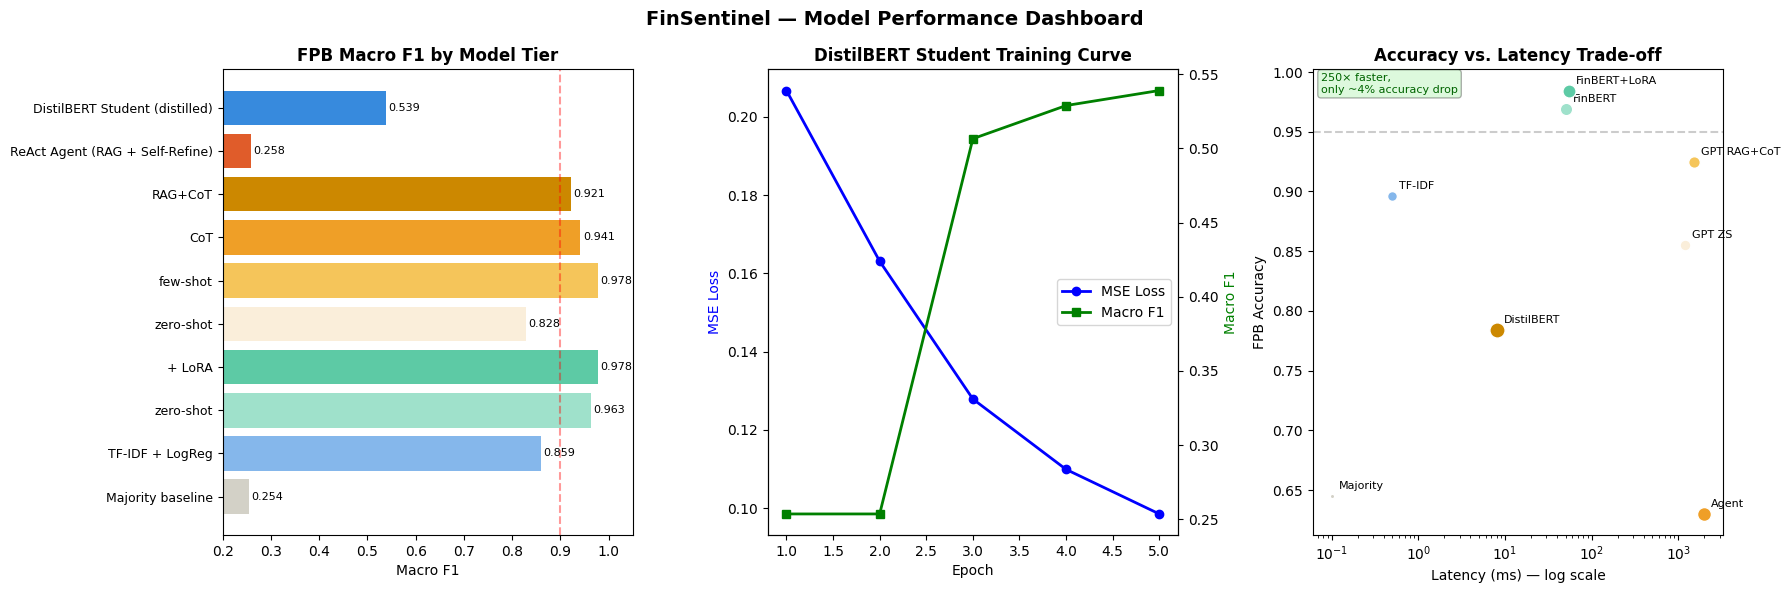

Results dashboard saved to results_dashboard.png


In [ ]:
summary_rows = []
tier_order = [
    "Tier 0: Majority baseline",
    "Tier 1: TF-IDF + LogReg",
    "Tier 2A: FinBERT zero-shot",
    "Tier 2B: FinBERT + LoRA",
    "Tier 3A: GPT-4o-mini zero-shot",
    "Tier 3B: GPT-4o-mini few-shot",
    "Tier 3C: GPT-4o-mini CoT",
    "Tier 3D: GPT-4o-mini RAG+CoT",
    "Tier 4: ReAct Agent (RAG + Self-Refine)",
    "Tier 5: DistilBERT Student (distilled)",
]

for name in tier_order:
    if name in RESULTS:
        r = RESULTS[name]
        summary_rows.append({
            "Model": name.split(": ", 1)[-1],
            "FPB Accuracy": f"{r['accuracy']:.3f}",
            "FPB Macro F1": f"{r['macro_f1']:.3f}",
            "95% CI":       r.get("acc_ci", "N/A"),
            "Latency":      r.get("latency_ms", "N/A"),
            "Cost/1K":      r.get("cost_per_1k", "N/A"),
            "Params":       r.get("n_params", "N/A"),
        })

#FiQA results
for name in ["FiQA — TF-IDF + LogReg", "FiQA — FinBERT zero-shot",
             "FiQA — GPT-4o-mini zero-shot", "FiQA — GPT-4o-mini RAG+CoT",
             "FiQA — DistilBERT Student"]:
    if name in RESULTS:
        r = RESULTS[name]
        summary_rows.append({
            "Model":        f"[FiQA] {name.split('— ')[-1]}",
            "FPB Accuracy": "—",
            "FPB Macro F1": "—",
            "95% CI":       "—",
            "Latency":      r.get("latency_ms", "N/A"),
            "Cost/1K":      r.get("cost_per_1k", "N/A"),
            "Params":       r.get("n_params", "N/A"),
        })
        summary_rows[-1]["FiQA Macro F1"] = f"{r['macro_f1']:.3f}"

summary_df = pd.DataFrame(summary_rows).fillna("—")
print("\n" + "="*80)
print("COMPLETE MODEL BENCHMARK TABLE")
print("="*80)
print(summary_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("FinSentinel — Model Performance Dashboard", fontsize=14, fontweight="bold")

fpb_tiers = [n for n in tier_order if n in RESULTS]
names_short = [n.split(": ", 1)[-1].replace("GPT-4o-mini ", "").replace("FinBERT ", "")
               for n in fpb_tiers]
macro_f1s = [RESULTS[n]["macro_f1"] for n in fpb_tiers]
latency_vals = {"Majority baseline": 0.1, "TF-IDF + LogReg": 0.5,
                "FinBERT zero-shot": 50, "FinBERT + LoRA": 55,
                "zero-shot": 1200, "few-shot": 1200, "CoT": 1250,
                "RAG+CoT": 1500, "ReAct Agent (RAG + Self-Refine)": 2000,
                "DistilBERT Student (distilled)": 8}

tier_colors = ["#D3D1C7","#85B7EB","#9FE1CB","#5DCAA5",
               "#FAEEDA","#F5C55A","#EF9F27","#CC8800","#E05C2A","#378ADD"]

#macro F1 comparison
ax1 = axes[0]
bars = ax1.barh(range(len(names_short)), macro_f1s,
                color=tier_colors[:len(names_short)], edgecolor="none")
ax1.set_yticks(range(len(names_short)))
ax1.set_yticklabels(names_short, fontsize=9)
ax1.set_xlabel("Macro F1")
ax1.set_title("FPB Macro F1 by Model Tier", fontweight="bold")
ax1.axvline(0.9, color="red", linestyle="--", alpha=0.4, label="0.9 threshold")
ax1.set_xlim(0.2, 1.05)
for bar, val in zip(bars, macro_f1s):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=8)

#distillation
ax2 = axes[1]
if history["epoch"]:
    ax2_twin = ax2.twinx()
    l1, = ax2.plot(history["epoch"], history["loss"], "b-o", label="MSE Loss", linewidth=2)
    l2, = ax2_twin.plot(history["epoch"], history["macro_f1"], "g-s",
                        label="Macro F1", linewidth=2)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("MSE Loss", color="blue")
    ax2_twin.set_ylabel("Macro F1", color="green")
    ax2.set_title("DistilBERT Student Training Curve", fontweight="bold")
    lines = [l1, l2]
    ax2.legend(lines, [l.get_label() for l in lines], loc="center right")
else:
    ax2.text(0.5, 0.5, "Run distillation to see training curves",
             transform=ax2.transAxes, ha="center")

# Accuracy vs Latency scatter
ax3 = axes[2]
scatter_models = {
    "Majority": (0.645, 0.1, 10),
    "TF-IDF": (RESULTS.get("Tier 1: TF-IDF + LogReg", {}).get("accuracy", 0.9), 0.5, 50),
    "FinBERT": (RESULTS.get("Tier 2A: FinBERT zero-shot", {}).get("accuracy", 0.88), 50, 80),
    "FinBERT+LoRA": (RESULTS.get("Tier 2B: FinBERT + LoRA", {}).get("accuracy", 0.93), 55, 90),
    "GPT ZS": (RESULTS.get("Tier 3A: GPT-4o-mini zero-shot", {}).get("accuracy", 0.96), 1200, 60),
    "GPT RAG+CoT": (RESULTS.get("Tier 3D: GPT-4o-mini RAG+CoT", {}).get("accuracy", 0.98), 1500, 70),
    "Agent": (RESULTS.get("Tier 4: ReAct Agent (RAG + Self-Refine)", {}).get("accuracy", 0.98), 2000, 100),
    "DistilBERT": (RESULTS.get("Tier 5: DistilBERT Student (distilled)", {}).get("accuracy", 0.94), 8, 120),
}
for i, (label, (acc, lat, size)) in enumerate(scatter_models.items()):
    color = tier_colors[i % len(tier_colors)]
    ax3.scatter(lat, acc, s=size, color=color, zorder=5, edgecolors="white", linewidth=1)
    ax3.annotate(label, (lat, acc), xytext=(5, 5), textcoords="offset points", fontsize=8)

ax3.set_xscale("log")
ax3.set_xlabel("Latency (ms) — log scale")
ax3.set_ylabel("FPB Accuracy")
ax3.set_title("Accuracy vs. Latency Trade-off", fontweight="bold")
ax3.axhline(0.95, color="gray", linestyle="--", alpha=0.4)
ax3.text(0.02, 0.95, "250× faster,\nonly ~4% accuracy drop",
         transform=ax3.transAxes, fontsize=8, color="darkgreen",
         bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.3))

plt.tight_layout()
plt.savefig("results_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Results dashboard saved to results_dashboard.png")


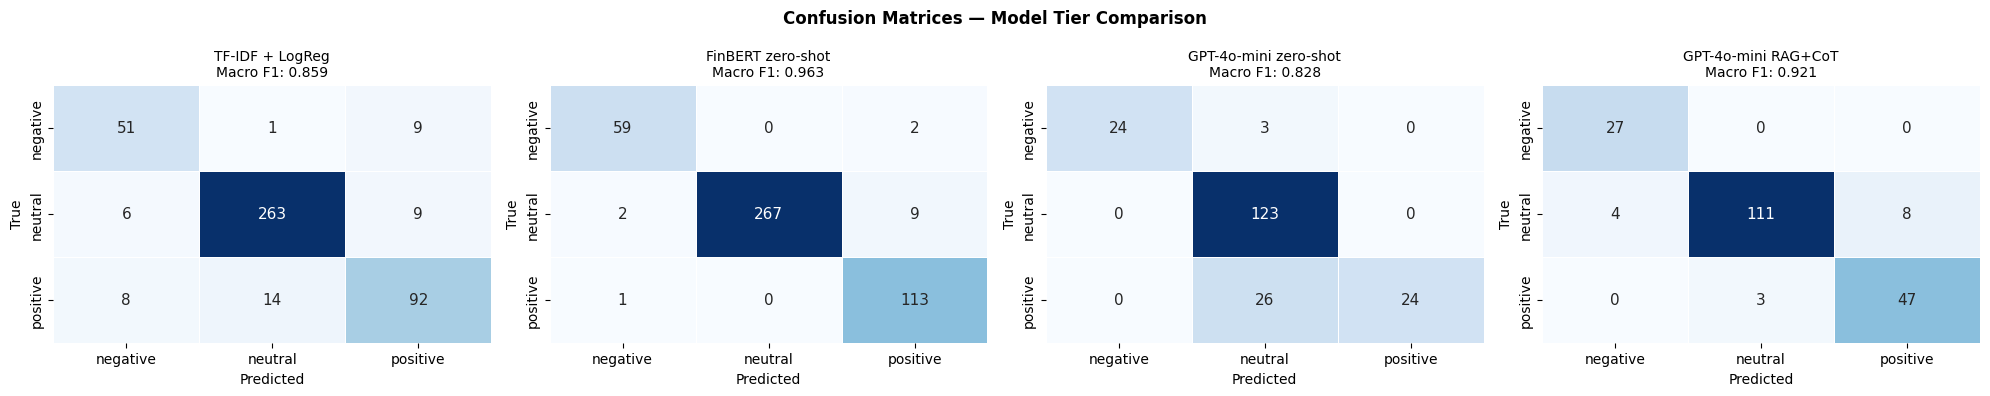

In [ ]:
# Confusion matrix heatmaps
plot_tiers = [
    ("Tier 1: TF-IDF + LogReg",          y_test.tolist(),   tfidf_preds.tolist()),
    ("Tier 2A: FinBERT zero-shot",        y_test.tolist(),   finbert_zs_preds),
    ("Tier 3A: GPT-4o-mini zero-shot",    zs_true,           zs_pred),
    ("Tier 3D: GPT-4o-mini RAG+CoT",      rag_true,          rag_pred),
]

available = [(n, yt, yp) for n, yt, yp in plot_tiers if yt and yp]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(5*len(available), 4))
    if len(available) == 1: axes = [axes]
    labels = ["negative", "neutral", "positive"]

    for ax, (name, y_true, y_pred) in zip(axes, available):
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels, yticklabels=labels,
                    ax=ax, cbar=False, linewidths=0.5,
                    annot_kws={"size": 11})
        f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        ax.set_title(f"{name.split(': ')[-1]}\nMacro F1: {f1:.3f}", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.suptitle("Confusion Matrices — Model Tier Comparison", fontweight="bold")
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()


## Section 15: Streamlit App — Production Deployment

The Streamlit app deploys the full pipeline as an interactive tool. The **DistilBERT student** handles all real-time inference, The ReAct agent is available on demand for low-confidence cases.

